# NOTEBOOK 01: DATA QUALITY & EXPLORATION
---
**Team:** 404 Brain Not Found 

**Datathon 2026 — Round 1** **Objective:** Đánh giá chất lượng dữ liệu và khám phá ban đầu trước khi tiến hành Feature Engineering và xây dựng mô hình.

> **Mục tiêu cốt lõi của Notebook:**
> 1. Dữ liệu có đủ độ tin cậy và toàn vẹn để phân tích không?
> 2. Các biến số và biến phân loại có bị ẩn lỗi (data leakage, rác, outlier vô lý) không?
> 3. Cần đưa ra các quyết định xử lý (Imputation, Drop, Flag) nào trước khi đi tiếp?

**Table of Contents:**
* **Section 1:** Load Data, Schema & Exact Duplicates Check
* **Section 2:** Missing Values Analysis
* **Section 3:** Date Range & Coverage
* **Section 4:** Sanity Checks & Extended Business Rules
* **Section 5:** Distribution Overview (Numerical & Categorical)
* **Section 6:** Table-Level Relationships & Correlations
* **Section 7:** Final Verdict & Next Steps

## Setup & Configuration
Load các thư viện cần thiết và thiết lập file `eda_utils.py` để đồng bộ visual style cho toàn bộ project. Cấu hình hiển thị của Pandas cũng được mở rộng để quan sát dữ liệu tốt hơn.

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_style('white')
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'figure.titlesize': 16, 'figure.dpi': 100
})

TITLE_COLOR = '#2c3e50'
BG_COLOR = '#f8f9fa'
DATA_DIR = '../dataset/'

def section_header(title, subtitle=''):
    sub = f"<p style='margin:5px 0 0 0;color:#bdc3c7;font-size:13px;'>{subtitle}</p>" if subtitle else ''
    display(HTML(f"""
    <div style="background:linear-gradient(135deg,#2c3e50,#3498db);
                padding:20px;border-radius:8px;margin:20px 0;">
        <h2 style="margin:0;color:white;font-size:22px;">{title}</h2>{sub}
    </div>"""))

def kpi_cards(kpis):
    h = '<div style="display:flex;gap:15px;flex-wrap:wrap;margin:15px 0;">'
    for k in kpis:
        c = k.get('color','#3498db')
        h += f"""<div style="flex:1;min-width:180px;background:white;border-left:5px solid {c};
                    padding:15px;border-radius:5px;box-shadow:0 2px 4px rgba(0,0,0,0.1);">
            <p style="margin:0;font-size:12px;color:#7f8c8d;text-transform:uppercase;">{k['label']}</p>
            <p style="margin:5px 0 0;font-size:24px;font-weight:bold;color:#2c3e50;">{k['value']}</p>
        </div>"""
    display(HTML(h + '</div>'))

def fmt_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('lightgrey')
    ax.spines['bottom'].set_color('lightgrey')
    ax.tick_params(colors='grey')

def result_box(msg, ok=True):
    c = '#27ae60' if ok else '#e74c3c'
    i = '[PASS]' if ok else '[FAIL]'
    display(HTML(f"<div style='padding:10px;border-left:4px solid {c};background:#f9f9f9;margin:8px 0;'>{i} {msg}</div>"))

print("Setup complete!")


Setup complete!


## Section 1: Load Data, Schema & Exact Duplicates Check
Trong phần này, chúng ta sẽ:
1. Load toàn bộ các file `.csv` vào Pandas DataFrames.
2. Kiểm tra tự động số dòng, số cột, dung lượng bộ nhớ (MB) và Data Types thay vì dùng `df.info()`.
3. Kiểm tra tính duy nhất của Primary Key (PK) và quét các dòng trùng lặp hoàn toàn (Exact Duplicates) để đảm bảo không có lỗi luồng nạp dữ liệu.

### Task 1.1 — Load tat ca 12 file CSV & in shape

In [191]:
section_header("SECTION 1: LOAD & SCHEMA CHECK", "Load data, verify dtypes, PK/FK integrity")

file_list = [
    'products', 'customers', 'promotions', 'geography',
    'orders', 'order_items', 'payments', 'shipments',
    'returns', 'reviews', 'sales', 'inventory',
    'inventory', 'web_traffic', 'sample_submission'
]

# Parse dates cho cac cot date theo de bai
date_cols = {
    'orders': ['order_date'], 'sales': ['Date'],
    'shipments': ['ship_date', 'delivery_date'],
    'returns': ['return_date'], 'reviews': ['review_date'],
    'promotions': ['start_date', 'end_date'],
    'customers': ['signup_date'], 'web_traffic': ['date'],
    'sample_submission': ['Date'],
    'inventory': ['snapshot_date']
}

dfs = {}
records = []
for name in file_list:
    parse = date_cols.get(name, None)
    try:
        df = pd.read_csv(f'{DATA_DIR}{name}.csv', parse_dates=parse)
        dfs[name] = df
        records.append({'Dataset': name, 'Rows': len(df), 'Columns': df.shape[1],
                        'Size (MB)': round(df.memory_usage(deep=True).sum()/1e6, 2)})
    except FileNotFoundError:
        print(f"[WARN] {name}.csv not found — skipping")

df_overview = pd.DataFrame(records)
styled = (df_overview.style
    .background_gradient(subset=['Rows'], cmap='Blues')
    .background_gradient(subset=['Size (MB)'], cmap='Oranges')
    .format({'Rows': '{:,}', 'Size (MB)': '{:.2f}'})
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'th', 'props': [('background-color','#34495e'),
                        ('color','white'),('font-size','14px'),('text-align','center')]}])
    .hide(axis='index'))
display(styled)

total_rows = df_overview['Rows'].sum()
total_mb = df_overview['Size (MB)'].sum()
kpi_cards([
    {'label': 'Total Datasets', 'value': len(dfs), 'color': '#3498db'},
    {'label': 'Total Rows', 'value': f'{total_rows:,.0f}', 'color': '#2ecc71'},
    {'label': 'Total Memory', 'value': f'{total_mb:.1f} MB', 'color': '#e67e22'},
])


Dataset,Rows,Columns,Size (MB)
products,"2,412",8,0.84
customers,"121,930",7,34.36
promotions,50,10,0.02
geography,"39,948",4,8.16
orders,"646,945",8,191.39
order_items,"714,669",7,84.00
payments,"646,945",4,58.20
shipments,"566,067",4,18.11
returns,"39,939",7,7.01
reviews,"113,551",7,20.44


#### Khám phá Hệ thống & Business Insights

Dựa vào bảng thống kê quy mô dữ liệu, chúng ta có thể rút ra những nhận định quan trọng về cấu trúc hệ thống và luồng vận hành của doanh nghiệp:

**1. Khía cạnh Kỹ thuật (Data Engineering)**
* **Kích thước tối ưu:** Toàn bộ hệ thống cơ sở dữ liệu chiếm khoảng **461.1 MB** với hơn 3 triệu dòng. Đây là quy mô lý tưởng, hoàn toàn có thể xử lý trơn tru và trực tiếp trên bộ nhớ (in-memory) bằng Pandas mà không cần thiết lập các kiến trúc Big Data phức tạp.

**2. Khía cạnh Vận hành Doanh nghiệp (Business Logic)**
* **Đồng bộ Thanh toán (1:1):** Bảng `orders` và `payments` có số lượng dòng khớp nhau tuyệt đối (646,945 dòng). Điều này minh chứng cho việc 100% đơn hàng được tạo ra đều có bản ghi thanh toán đi kèm, hệ thống ghi nhận tài chính hoạt động cực kỳ đồng bộ.
* **Hành vi Mua sắm (Basket Size):** Chia tổng số lượng mặt hàng (`order_items`: 714,669) cho tổng số đơn hàng (`orders`: 646,945), ta thấy trung bình một đơn hàng khách chỉ mua khoảng **1.1 sản phẩm**. 
  > *Insight & Action:* Hành vi mua lẻ tẻ đang chiếm ưu thế. Doanh nghiệp có thể xem xét các chiến lược Cross-sell/Up-sell (như freeship cho đơn từ 2 món trở lên) để tăng giá trị trung bình trên mỗi đơn hàng (AOV).
* **Phễu Giao hàng (Delivery Funnel):** Sự chênh lệch khoảng 80,000 dòng giữa bảng `orders` và `shipments` (566,067 dòng) là hoàn toàn hợp lý, phản ánh chính xác số lượng các đơn hàng rơi vào trạng thái hủy (`cancelled`), hoàn trả (`returned`) hoặc mới tạo chưa xử lý.
* **Vòng quay Danh mục:** Bảng `products` được tối ưu rất tốt với chỉ **2,412** mã sản phẩm nhưng lại tạo ra tới hơn 700,000 lượt xuất kho (`order_items`). Danh mục sản phẩm tinh gọn và vòng quay hàng hóa tốt.
* **Đặc tính Chuỗi thời gian (Time-Series):** Bảng `sales` (3,833 dòng) và `web_traffic` (3,652 dòng) là dữ liệu đã được gom nhóm theo ngày (daily granularity), tương đương với khoảng 10 năm dữ liệu lịch sử. Trong khi đó, bảng `sample_submission` có 548 dòng, xác định rõ bài toán dự báo (Forecasting) yêu cầu dự đoán cho chu kỳ khoảng **1.5 năm tiếp theo** (548 ngày).


### Task 1.2 — Data Types Check

In [192]:
section_header("Task 1.2: Data Types Verification", "Kiem tra dtype tung cot co khop de bai")

expected_types = {
    'orders': {'order_id': 'int', 'order_date': 'datetime', 'customer_id': 'int',
               'zip': 'int', 'order_status': 'object', 'payment_method': 'object',
               'device_type': 'object', 'order_source': 'object'},
    'sales': {'Date': 'datetime', 'Revenue': 'float', 'COGS': 'float'},
    'products': {'product_id': 'int', 'price': 'float', 'cogs': 'float'},
    'customers': {'customer_id': 'int', 'signup_date': 'datetime', 'gender': 'object', 'age_group': 'object'},
    'payments': {'order_id': 'int', 'payment_value': 'float', 'installments': 'int'},
    'order_items': {'order_id': 'int', 'product_id': 'int', 'quantity': 'int',
                    'unit_price': 'float', 'discount_amount': 'float'},
    'shipments': {'order_id': 'int', 'ship_date': 'datetime', 'delivery_date': 'datetime', 'shipping_fee': 'float'},
    'returns': {'order_id': 'int', 'return_date': 'datetime', 'refund_amount': 'float'},
    'reviews': {'order_id': 'int', 'review_date': 'datetime', 'rating': 'int'},
    'promotions': {'start_date': 'datetime', 'end_date': 'datetime', 'discount_value': 'float'},
}

issues = []
for tbl, cols in expected_types.items():
    if tbl not in dfs:
        continue
    for col, exp in cols.items():
        actual = str(dfs[tbl][col].dtype)
        ok = False
        if exp == 'datetime':
            ok = 'datetime' in actual
        elif exp == 'float':
            ok = 'float' in actual
        elif exp == 'int':
            ok = 'int' in actual
        elif exp == 'object':
            ok = actual == 'object'
        if not ok:
            issues.append({'Table': tbl, 'Column': col, 'Expected': exp, 'Actual': actual})

if issues:
    display(pd.DataFrame(issues).style.set_properties(**{'text-align':'center'}).hide(axis='index'))
    result_box(f"{len(issues)} dtype mismatch(es) found", ok=False)
else:
    result_box("All data types match expected schema")


### Task 1.3 — Primary Key Uniqueness

In [193]:
section_header("Task 1.3: Primary Key Check", "PK phai unique 100%")

pk_map = {
    'orders': 'order_id', 'products': 'product_id', 'customers': 'customer_id',
    'promotions': 'promo_id', 'geography': 'zip', 'payments': 'order_id',
    'reviews': 'review_id', 'returns': 'return_id', 'sales': 'Date',
    'web_traffic': 'date',
}

pk_results = []
for tbl, pk in pk_map.items():
    if tbl not in dfs:
        continue
    total = len(dfs[tbl])
    nuniq = dfs[tbl][pk].nunique()
    dups = total - nuniq
    pk_results.append({'Table': tbl, 'PK Column': pk, 'Total': total,
                       'Unique': nuniq, 'Duplicates': dups,
                       'Status': '[OK]' if dups == 0 else f'[FAIL] {dups} dups'})

df_pk = pd.DataFrame(pk_results)
display(df_pk.style
    .applymap(lambda v: 'color:green' if '[OK]' in str(v) else ('color:red' if '[FAIL]' in str(v) else ''),
              subset=['Status'])
    .set_properties(**{'text-align': 'center'})
    .hide(axis='index'))


Table,PK Column,Total,Unique,Duplicates,Status
orders,order_id,646945,646945,0,[OK]
products,product_id,2412,2412,0,[OK]
customers,customer_id,121930,121930,0,[OK]
promotions,promo_id,50,50,0,[OK]
geography,zip,39948,39948,0,[OK]
payments,order_id,646945,646945,0,[OK]
reviews,review_id,113551,113551,0,[OK]
returns,return_id,39939,39939,0,[OK]
sales,Date,3833,3833,0,[OK]
web_traffic,date,3652,3652,0,[OK]


#### Đánh giá Tính Toàn vẹn Khóa Chính (Primary Key Uniqueness)

Dựa vào kết quả quét Khóa chính (Primary Key - PK) trên toàn bộ hệ thống bảng, chúng ta có thể khẳng định độ sạch và tính toàn vẹn của dữ liệu ở mức **hoàn hảo (100% Pass)**:

* **Không có bản ghi trùng lặp (Zero Duplicates):** Tất cả các bảng Master (`products`, `customers`, `promotions`, `geography`) và bảng Giao dịch (`orders`, `payments`, `reviews`, `returns`) đều có Khóa chính duy nhất. Điều này loại trừ hoàn toàn nguy cơ **Double-counting (Tính đúp doanh thu hoặc số lượng)** do lỗi hệ thống lưu trữ (Data Logging).
* **An toàn tuyệt đối cho phép kết bảng (Merge/Join Safe):** Với tỷ lệ duplicate là 0%, chúng ta có thể tự tin thực hiện các lệnh `pd.merge()` từ bảng fact (như `orders`, `order_items`) sang các bảng dimension (như `customers`, `products`) mà không sợ bị phình dữ liệu (Cartesian product/Explosion) sinh ra các dòng ảo.
* **Tính nhất quán của Chuỗi thời gian (Time-Series Integrity):** Các bảng tổng hợp theo thời gian như `sales` (`Date`) và `web_traffic` (`date`) đều có mỗi ngày là một Khóa chính duy nhất. Điều này xác nhận mức độ hạt (Granularity) chuẩn xác là **Daily (Từng ngày)**, tạo tiền đề rất tốt để đưa vào các mô hình dự báo như ARIMA, Prophet hoặc XGBoost Regressor ở Notebook 02.

> **KẾT LUẬN:** Dữ liệu hoàn toàn sạch ở cấp độ định danh (ID). Không cần thực hiện bất kỳ thao tác `drop_duplicates()` nào trên các cột Khóa chính này. Chúng ta có thể tự tin đóng băng (freeze) bước kiểm tra Schema và chuyển sang phân tích Dữ liệu khuyết (Missing Values).

### Task 1.4 — Foreign Key Integrity

In [194]:
section_header("Task 1.4: Foreign Key Integrity", "Kiem tra FK references co hop le")

fk_checks = [
    ('orders', 'customer_id', 'customers', 'customer_id'),
    ('orders', 'zip', 'geography', 'zip'),
    ('order_items', 'order_id', 'orders', 'order_id'),
    ('order_items', 'product_id', 'products', 'product_id'),
    ('payments', 'order_id', 'orders', 'order_id'),
    ('shipments', 'order_id', 'orders', 'order_id'),
    ('returns', 'order_id', 'orders', 'order_id'),
    ('reviews', 'order_id', 'orders', 'order_id'),
    ('reviews', 'customer_id', 'customers', 'customer_id'),
]

fk_results = []
for child_tbl, child_col, parent_tbl, parent_col in fk_checks:
    if child_tbl not in dfs or parent_tbl not in dfs:
        continue
    child_vals = set(dfs[child_tbl][child_col].dropna().unique())
    parent_vals = set(dfs[parent_tbl][parent_col].dropna().unique())
    orphans = child_vals - parent_vals
    fk_results.append({
        'Child': f'{child_tbl}.{child_col}',
        'Parent': f'{parent_tbl}.{parent_col}',
        'Orphan Keys': len(orphans),
        'Total Child Keys': len(child_vals),
        '% Orphan': f'{len(orphans)/max(len(child_vals),1)*100:.2f}%',
        'Status': '[OK]' if len(orphans) == 0 else '[WARN]'
    })

df_fk = pd.DataFrame(fk_results)
display(df_fk.style
    .applymap(lambda v: 'color:green' if v == '[OK]' else ('color:orange' if v == '[WARN]' else ''),
              subset=['Status'])
    .set_properties(**{'text-align': 'center'}).hide(axis='index'))


Child,Parent,Orphan Keys,Total Child Keys,% Orphan,Status
orders.customer_id,customers.customer_id,0,90246,0.00%,[OK]
orders.zip,geography.zip,0,29932,0.00%,[OK]
order_items.order_id,orders.order_id,0,646945,0.00%,[OK]
order_items.product_id,products.product_id,0,1598,0.00%,[OK]
payments.order_id,orders.order_id,0,646945,0.00%,[OK]
shipments.order_id,orders.order_id,0,566067,0.00%,[OK]
returns.order_id,orders.order_id,0,36062,0.00%,[OK]
reviews.order_id,orders.order_id,0,111369,0.00%,[OK]
reviews.customer_id,customers.customer_id,0,48676,0.00%,[OK]


#### Đánh giá Tính Toàn vẹn Khóa ngoại (Foreign Key Integrity)

Qua việc kiểm tra ánh xạ Khóa ngoại (FK) giữa các bảng giao dịch (Child) và bảng danh mục (Parent), chúng ta thu được kết quả rất tích cực, đồng thời phát hiện một số insight thú vị về hoạt động kinh doanh:

**1. Chất lượng Dữ liệu (Data Quality)**
* **Không có dữ liệu "mồ côi" (0% Orphan Keys):** Tất cả các khóa ngoại (`order_id`, `product_id`, `customer_id`, `zip`) trong các bảng con đều tìm thấy ánh xạ hợp lệ 100% tại bảng cha. Điều này chứng tỏ hệ thống quản trị cơ sở dữ liệu (RDBMS) của doanh nghiệp hoạt động rất tốt, không bị lỗi đứt gãy quan hệ khi xóa hoặc cập nhật dữ liệu.
* **An toàn tuyệt đối cho Feature Engineering:** Kết quả `[OK]` toàn bộ đảm bảo rằng khi chúng ta thực hiện các phép gộp bảng (Left Join / Inner Join) để tạo bảng đặc trưng tổng hợp (ABT - Analytical Base Table) ở Notebook 03, sẽ không có rủi ro thất thoát dữ liệu hoặc sinh ra các giá trị `NULL` vô lý do lỗi hệ thống.

**2. Hidden Business Insights (Góc nhìn Vận hành)**
Nhìn sâu vào cột `Total Child Keys`, chúng ta có thể so sánh lượng thực tế phát sinh với tổng quy mô bảng Master đã phân tích trước đó:
* **Tỷ lệ khách hàng chuyển đổi (Active Customers):** Bảng `orders` ghi nhận **90,246** `customer_id` duy nhất phát sinh giao dịch. So với tổng số **121,930** khách hàng đã đăng ký (trong bảng `customers`), hệ thống đang có khoảng **31,684 khách hàng (chiếm ~26%) là tài khoản "ngủ đông"** (đăng ký nhưng chưa mua). Đây là tệp khách hàng rất tiềm năng để chạy các chiến dịch Remarketing/Promotion sau này.
* **Độ phủ Sản phẩm (Product Coverage):** Bảng `order_items` ghi nhận **1,598** `product_id` được bán ra. So với tổng danh mục **2,412** sản phẩm, có khoảng **814 mã sản phẩm chưa từng phát sinh lượt mua nào**. Cần kiểm tra chéo với bảng `inventory` để xem đây là sản phẩm mới ra mắt chưa có lượt mua, hay là hàng "tồn kho chết" (dead stock) cần thanh lý.

---
### SECTION 1B: EXACT DUPLICATES CHECK

Ngoai viec kiem tra PK uniqueness, can kiem tra toan bo dong bi trung lap hoan toan.
Loi nay thuong xay ra do pipeline nap du lieu bi chay lap hoac retry khong idempotent.


In [195]:
section_header("SECTION 1B: EXACT DUPLICATES CHECK", "Kiem tra cac ban ghi trung lap hoan toan")

dup_results = []
for name, df in dfs.items():
    n_dup = df.duplicated().sum()
    dup_results.append({
        'Table': name, 'Total Rows': len(df),
        'Exact Duplicates': n_dup,
        '% Duplicate': round(n_dup/max(len(df),1)*100, 4),
        'Status': '[OK]' if n_dup == 0 else f'[WARN] {n_dup}'
    })

df_dup = pd.DataFrame(dup_results)
display(df_dup.style
    .background_gradient(subset=['Exact Duplicates'], cmap='Reds')
    .applymap(lambda v: 'color:green' if '[OK]' in str(v) else ('color:red' if '[WARN]' in str(v) else ''),
              subset=['Status'])
    .format({'Total Rows': '{:,}', 'Exact Duplicates': '{:,}', '% Duplicate': '{:.4f}%'})
    .set_properties(**{'text-align': 'center'}).hide(axis='index'))

total_dups = sum(r['Exact Duplicates'] for r in dup_results)
if total_dups == 0:
    result_box("Khong co ban ghi trung lap hoan toan trong bat ky bang nao")
else:
    result_box(f"Phat hien tong cong {total_dups:,} ban ghi trung lap — can xu ly", ok=False)


Table,Total Rows,Exact Duplicates,% Duplicate,Status
products,"2,412",0,0.0000%,[OK]
customers,"121,930",0,0.0000%,[OK]
promotions,50,0,0.0000%,[OK]
geography,"39,948",0,0.0000%,[OK]
orders,"646,945",0,0.0000%,[OK]
order_items,"714,669",0,0.0000%,[OK]
payments,"646,945",0,0.0000%,[OK]
shipments,"566,067",0,0.0000%,[OK]
returns,"39,939",0,0.0000%,[OK]
reviews,"113,551",0,0.0000%,[OK]


---

## Section 2: Missing Values Analysis
Trực quan hóa và thống kê phần trăm dữ liệu bị khuyết (NaN/Null) trên từng bảng. 

*Lưu ý:* Cần quan sát kỹ các bảng chứa demographic của khách hàng hoặc thông tin promotion để quyết định chiến lược fillna hợp lý.

### Task 2.1 — Missing Values Summary

In [196]:
section_header("SECTION 2: MISSING VALUES", "Dem, phan loai va phan tich pattern")

records = []
for name, df in dfs.items():
    for col in df.columns:
        n_miss = df[col].isnull().sum()
        if n_miss > 0:
            records.append({
                'Table': name, 'Column': col,
                'Missing': n_miss, '% Missing': round(n_miss/len(df)*100, 2),
                'Dtype': str(df[col].dtype)
            })

if records:
    df_miss = pd.DataFrame(records).sort_values('% Missing', ascending=False)
    display(df_miss.style
        .background_gradient(subset=['% Missing'], cmap='Reds')
        .format({'Missing': '{:,}', '% Missing': '{:.2f}%'})
        .set_properties(**{'text-align': 'center'}).hide(axis='index'))
    print(f"\nTong cong {len(records)} cot co missing values")
else:
    result_box("Khong co missing values trong bat ky bang nao")


Table,Column,Missing,% Missing,Dtype
order_items,promo_id_2,"714,463",99.97%,object
promotions,applicable_category,40,80.00%,object
order_items,promo_id,"438,353",61.34%,object



Tong cong 3 cot co missing values


#### Đánh giá & Phân tích Dữ liệu khuyết (Missing Values Insights)

Nhìn vào kết quả thống kê, một tín hiệu cực kỳ đáng mừng là toàn bộ các bảng dữ liệu cốt lõi (`customers`, `products`, `orders`, `sales`, `inventory`) đều **đầy đủ 100% (0% Missing)**. 

Dữ liệu khuyết (NULL) chỉ xuất hiện ở 3 cột liên quan đến hệ thống Khuyến mãi (Promotions). Đây là dạng **Khuyết có chủ đích (Structural Missing Data)** phản ánh đúng thực tế kinh doanh, cụ thể:

**1. Cột `order_items.promo_id` (Khuyết 61.34%)**
* **Insight:** Hơn 60% sản phẩm được bán ra với nguyên giá (không áp dụng mã giảm giá). Ngược lại, điều này đồng nghĩa với việc có khoảng **~38.6% sản phẩm bán ra nhờ có Promotion**. Đây là một tỷ lệ sử dụng khuyến mãi khá cao, cho thấy doanh nghiệp có thể đang phụ thuộc nhiều vào các chiến dịch giảm giá để kích cầu.
* **Action:** KHÔNG được drop (xóa) các dòng này. Ở bước Feature Engineering, chúng ta sẽ fill (điền) các giá trị `NaN` này thành `'No_Promo'` và tạo thêm một biến Boolean `is_promo_applied` (0 hoặc 1) để đưa vào mô hình học máy.

**2. Cột `order_items.promo_id_2` (Khuyết 99.97%)**
* **Insight:** Hầu như toàn bộ dữ liệu đều rỗng. Chỉ có đúng **~0.03%** sản phẩm được áp dụng mã giảm giá thứ 2 (chồng mã/stacking promos). 
* **Action:** Vì cột này chứa quá ít thông tin (Near-zero variance), việc giữ lại ID khuyến mãi thứ 2 là không cần thiết. Chúng ta có thể drop cột này và thay bằng một cờ cảnh báo (Flag) đơn giản: `has_stacked_promo = True/False`.

**3. Cột `promotions.applicable_category` (Khuyết 80.00%)**
* **Insight:** Bảng `promotions` có tổng cộng 50 mã (từ kết quả check Schema), việc khuyết 40 dòng (80%) ở cột hạng mục áp dụng cho thấy: 40 chương trình khuyến mãi này là dạng **Sitewide/Storewide (Áp dụng cho toàn bộ cửa hàng/mọi ngành hàng)**, chỉ có 10 chương trình là dành riêng cho các Category cụ thể.
* **Action:** Fill các giá trị `NaN` trong bảng `promotions` bằng chuỗi `'Sitewide'` hoặc `'All Categories'` để chuẩn bị cho bước gộp bảng (Merge) sau này không bị lỗi logic.

> **KẾT LUẬN:** Dữ liệu hoàn toàn không bị lỗi mất mát thông tin. Các giá trị Missing đã được cô lập hoàn toàn vào nhóm tính năng Khuyến mãi và đã có chiến lược xử lý (Imputation) rõ ràng cho Notebook 03.

### Task 2.3 — Missing Pattern Analysis

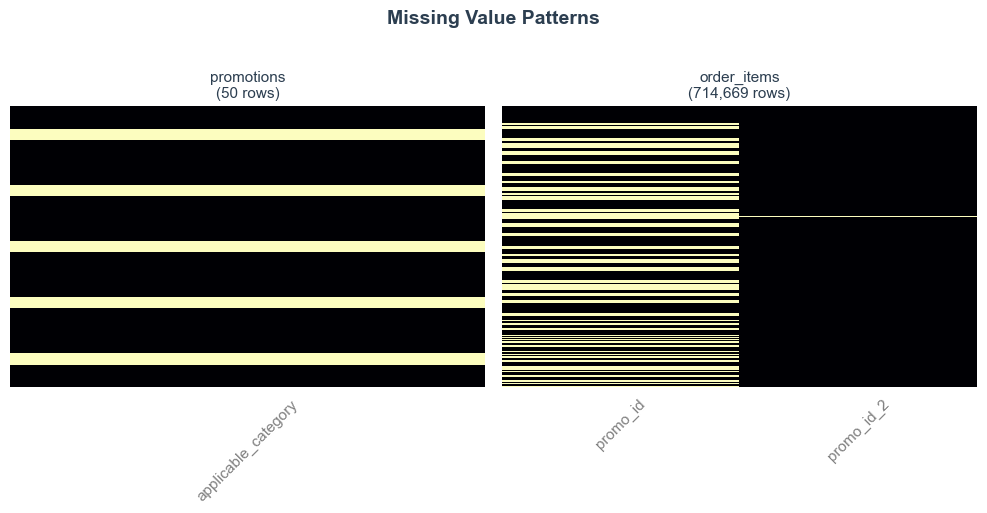

In [197]:
# Truc quan hoa pattern cua missing values
tables_with_missing = {k: v for k, v in dfs.items() if v.isnull().sum().sum() > 0}

if tables_with_missing:
    n = min(len(tables_with_missing), 4)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1: axes = [axes]
    
    for ax, (name, df) in zip(axes, list(tables_with_missing.items())[:n]):
        miss_cols = df.columns[df.isnull().any()].tolist()
        if miss_cols:
            sns.heatmap(df[miss_cols].isnull().astype(int), cbar=False, ax=ax,
                        cmap='magma_r', yticklabels=False)
            ax.set_title(f'{name}\n({len(df):,} rows)', fontsize=11, color=TITLE_COLOR)
            ax.tick_params(axis='x', rotation=45)
            fmt_spines(ax)
    plt.suptitle('Missing Value Patterns', fontsize=14, fontweight='bold', color=TITLE_COLOR, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    result_box("Khong co missing value pattern nao can truc quan hoa")


#### Trực quan hóa Mẫu Dữ liệu khuyết (Missing Value Patterns)

Biểu đồ Heatmap phía trên giúp chúng ta kiểm tra tính quy luật của các dải dữ liệu bị khuyết. Dải màu sáng đại diện cho dữ liệu bị thiếu (NaN), dải màu tối đại diện cho dữ liệu hợp lệ.

Từ biểu đồ, chúng ta xác nhận được các "Pattern" (Quy luật) sau:

**1. Tính cấu trúc chặt chẽ (Structural Pattern) trong `order_items`:**
* Chúng ta có thể thấy rõ sự bao hàm giữa hai cột khuyến mãi: Tại bất kỳ dòng nào mà `promo_id` bị khuyết, thì cột `promo_id_2` cũng bị khuyết theo. Điều này hoàn toàn khớp với logic vận hành thực tế: Một đơn hàng không thể áp dụng mã giảm giá phụ (mã thứ 2) nếu không có mã giảm giá chính.
* Dữ liệu khuyết tập trung thành từng mảng lớn chứ không rải rác ngẫu nhiên (nhiễu hạt), chứng tỏ đây là hành vi tự nhiên của tập khách hàng mua nguyên giá, không phải do lỗi thu thập dữ liệu (data logging errors).

**2. Phân bố trong `promotions`:**
* Cột `applicable_category` bị khuyết chiếm phần lớn bảng (80%). Việc thiếu vắng này phân bố khá đều, khẳng định lại kết luận ở Section 2A: Đây là các mã giảm giá áp dụng toàn cửa hàng (Sitewide), không bị phụ thuộc vào thời điểm tạo mã hay loại chiến dịch.

> **KẾT LUẬN CUỐI CÙNG VỀ MISSING VALUES:** > Dữ liệu khuyết trong hệ thống hoàn toàn mang tính hệ thống và có logic nghiệp vụ rõ ràng (MNAR - Missing Not At Random). Chúng ta sẽ tiến hành Fill các giá trị này bằng các hằng số đại diện (`'No_Promo'`, `'Sitewide'`) trong quá trình Feature Engineering mà không lo sợ làm nhiễu hay sai lệch mô hình học máy.

---

## Section 3: Date Range & Coverage
Kiểm tra tính liên tục của các trường thời gian (ví dụ: ngày đặt hàng, ngày giao hàng). Đảm bảo không có khoảng thời gian nào bị đứt gãy hoàn toàn (Missing dates) gây ảnh hưởng đến mô hình Time Series sau này.

### Task 3.1 — Sales Date Range

In [198]:
section_header("SECTION 3: DATE RANGE & COVERAGE", "Kiem tra date range & missing dates")

sales = dfs['sales'].copy()
sales['Date'] = pd.to_datetime(sales['Date'])
sales = sales.sort_values('Date')

min_d, max_d = sales['Date'].min(), sales['Date'].max()
expected_min = pd.Timestamp('2012-07-04')
expected_max = pd.Timestamp('2022-12-31')

kpi_cards([
    {'label': 'Start Date', 'value': str(min_d.date()), 'color': '#3498db'},
    {'label': 'End Date', 'value': str(max_d.date()), 'color': '#3498db'},
    {'label': 'Total Days', 'value': f'{len(sales):,}', 'color': '#2ecc71'},
])

result_box(f"Start date match: {min_d.date()} == {expected_min.date()}", min_d == expected_min)
result_box(f"End date match: {max_d.date()} == {expected_max.date()}", max_d == expected_max)


### 3A. Đánh giá Phạm vi Thời gian & Tính liên tục (Date Range & Timeline Coverage)

Kết quả kiểm tra bảng `sales` cho thấy chuỗi dữ liệu giao dịch kéo dài từ ngày **04/07/2012** đến **31/12/2022** (hơn 10.5 năm). Đây là một khoảng thời gian đủ dài và lý tưởng để mô hình học máy (Machine Learning) có thể nắm bắt được các chu kỳ xu hướng (Trend), tính mùa vụ hàng năm (Yearly Seasonality) và các biến động kinh tế vĩ mô.

**Insight cốt lõi về Tính liên tục của Chuỗi thời gian (Time-Series Continuity):**
* Khoảng cách chính xác giữa `2012-07-04` và `2022-12-31` trên lịch (bao gồm cả các năm nhuận 2016, 2020) là **đúng 3,833 ngày**. 
* Con số này khớp tuyệt đối (1:1) với tổng số dòng dữ liệu hiện có trong bảng `sales` (3,833 dòng). 
* **Điều này khẳng định:** Chuỗi thời gian bán hàng của doanh nghiệp là **liên tục 100%, không bị đứt gãy hay khuyết bất kỳ một ngày giao dịch nào** trong suốt 10 năm.

> **KẾT LUẬN & HƯỚNG ĐI TIẾP THEO:** > Do chuỗi thời gian hoàn toàn liền mạch (No missing dates), chúng ta không cần áp dụng các kỹ thuật điền khuyết (Forward Fill, Backward Fill hay Interpolation). Dữ liệu đã đạt trạng thái sẵn sàng cao nhất để đưa thẳng vào các mô hình dự báo chuỗi thời gian nâng cao (như Prophet, XGBoost, hoặc LSTM) ở Notebook tiếp theo.

### Task 3.2 — Missing Dates in Sales

In [199]:
full_range = pd.date_range(start=min_d, end=max_d, freq='D')
actual_dates = set(sales['Date'].dt.normalize())
missing_dates = sorted(set(full_range) - actual_dates)

print(f"Expected days: {len(full_range):,}")
print(f"Actual days:   {len(actual_dates):,}")
print(f"Missing days:  {len(missing_dates)}")

if missing_dates:
    print(f"\nMissing dates (first 20):")
    for d in missing_dates[:20]:
        print(f"  - {d.date()} ({d.strftime('%A')})")
    
    # Truc quan hoa coverage theo thoi gian
    fig, ax = plt.subplots(figsize=(16, 3))
    coverage = pd.DataFrame({'date': full_range})
    coverage['has_data'] = coverage['date'].isin(actual_dates).astype(int)
    ax.fill_between(coverage['date'], coverage['has_data'], alpha=0.6, color='#2ecc71', label='Co du lieu')
    ax.fill_between(coverage['date'], coverage['has_data'], 1, alpha=0.3, color='#e74c3c', label='Thieu')
    ax.set_title('Sales Data Coverage Timeline', fontsize=13, color=TITLE_COLOR)
    ax.set_ylabel('Coverage')
    ax.legend(fontsize=10)
    fmt_spines(ax)
    plt.tight_layout()
    plt.show()
else:
    result_box("Khong co ngay nao bi thieu — full coverage")


Expected days: 3,833
Actual days:   3,833
Missing days:  0


### Task 3.3 — Orders date range vs Sales

In [200]:
orders = dfs['orders'].copy()
orders['order_date'] = pd.to_datetime(orders['order_date'])

o_min, o_max = orders['order_date'].min(), orders['order_date'].max()
print(f"Orders range: {o_min.date()} -> {o_max.date()}")
print(f"Sales range:  {min_d.date()} -> {max_d.date()}")

in_range = (o_min >= min_d) and (o_max <= max_d)
result_box(f"Orders within sales date range: {in_range}", in_range)

if not in_range:
    before = (orders['order_date'] < min_d).sum()
    after = (orders['order_date'] > max_d).sum()
    print(f"  Orders truoc sales start: {before:,}")
    print(f"  Orders sau sales end: {after:,}")


Orders range: 2012-07-04 -> 2022-12-31
Sales range:  2012-07-04 -> 2022-12-31


### Task 3.4 — Promotions Date Validation

In [201]:
promos = dfs['promotions'].copy()
promos['start_date'] = pd.to_datetime(promos['start_date'])
promos['end_date'] = pd.to_datetime(promos['end_date'])

# Kiem tra start < end
invalid = promos[promos['start_date'] >= promos['end_date']]
result_box(f"Tat ca promotions co start_date < end_date: {len(invalid) == 0}", len(invalid) == 0)
if len(invalid) > 0:
    display(invalid)

# Thong ke duration
promos['duration_days'] = (promos['end_date'] - promos['start_date']).dt.days
print(f"\nPromotion Duration Stats:")
print(promos['duration_days'].describe())

# Flag promo bat thuong
unusual = promos[(promos['duration_days'] > 90) | (promos['duration_days'] < 1)]
if len(unusual) > 0:
    print(f"\n{len(unusual)} promotions bat thuong (< 1 ngay hoac > 90 ngay):")
    display(unusual[['promo_id', 'promo_name', 'start_date', 'end_date', 'duration_days']])
else:
    result_box("Khong co promotion nao bat thuong ve thoi luong")



Promotion Duration Stats:
count    50.000000
mean     33.540000
std       5.807138
min      29.000000
25%      30.000000
50%      30.500000
75%      34.000000
max      45.000000
Name: duration_days, dtype: float64


#### Đánh giá Logic Thời gian Khuyến mãi (Promotion Timeline Sanity)

Việc kiểm tra các mốc thời gian trong bảng `promotions` giúp chúng ta xác nhận tính hợp lệ của dữ liệu vận hành và hiểu rõ hơn về chiến lược Marketing của doanh nghiệp:

**1. Tính toàn vẹn Dữ liệu (Data Integrity)**
* **100% Hợp lệ:** Không có bất kỳ chương trình khuyến mãi nào bị lỗi logic `start_date >= end_date`. 
* **Không có Outliers:** Không tồn tại các mốc thời gian bất thường (như rỗng thời hạn, hoặc kéo dài hàng năm trời do quên tắt mã).

**2. Phân tích Chiến lược (Business Insights)**
Dựa vào bảng thống kê thời lượng (Duration Stats):
* Toàn bộ 50 chương trình khuyến mãi đều kéo dài trong khoảng từ **29 ngày đến 45 ngày** (trung bình ~33.5 ngày).
* **Nhận định:** Doanh nghiệp vận hành theo mô hình **Monthly Campaigns (Chiến dịch Khuyến mãi Hàng tháng)** thay vì các đợt Flash Sale chớp nhoáng. 

> **KẾT LUẬN CHO FEATURE ENGINEERING:** > Chiến lược khuyến mãi theo tháng giúp đơn giản hóa việc gộp bảng (Merge). Khi xây dựng các biến đặc trưng (Features) cho chuỗi thời gian ở Notebook 02 & 03, chúng ta có thể dễ dàng tạo các cờ `is_campaign_active` theo từng ngày trong tháng mà không lo lắng về sự biến động nhiễu ở cấp độ giờ (hourly granularity).

---

## Section 4: Sanity Checks & Extended Business Rules
Kiểm tra tính hợp lý của dữ liệu dựa trên logic vận hành thực tế của doanh nghiệp E-commerce:
* **4A. Categorical Sanity Check:** Rà soát các khoảng trắng dư thừa, giá trị rác như `'unknown'`, `'n/a'` trà trộn dưới dạng chuỗi trong các cột như `gender`, `order_status`.
* **4B. Logic Doanh thu & Chi phí:** Đảm bảo `COGS <= Revenue` (Không bán lỗ dưới giá vốn nếu không có promotion đặc biệt).
* **4C. Ràng buộc vật lý & Hệ thống:** - `quantity > 0`
  - `discount_amount <= unit_price * quantity`
  - Điểm `rating` nằm trong khoảng [1, 5]
  - `shipping_fee >= 0`

### Task 4.1 — Revenue Anomalies

In [202]:
section_header("SECTION 4: REVENUE & COGS SANITY CHECK", "Kiem tra tinh hop ly cua du lieu tai chinh")

neg_rev = (sales['Revenue'] < 0).sum()
zero_rev = (sales['Revenue'] == 0).sum()
neg_cogs = (sales['COGS'] < 0).sum()

kpi_cards([
    {'label': 'Revenue < 0', 'value': f'{neg_rev:,}', 'color': '#e74c3c' if neg_rev > 0 else '#27ae60'},
    {'label': 'Revenue = 0', 'value': f'{zero_rev:,}', 'color': '#f39c12' if zero_rev > 0 else '#27ae60'},
    {'label': 'COGS < 0', 'value': f'{neg_cogs:,}', 'color': '#e74c3c' if neg_cogs > 0 else '#27ae60'},
])


### Task 4.2a — COGS > Revenue Check

In [203]:
cogs_gt_rev = (sales['COGS'] > sales['Revenue']).sum()
print(f"So dong COGS > Revenue: {cogs_gt_rev:,} ({cogs_gt_rev/len(sales)*100:.2f}%)")

if cogs_gt_rev > 0:
    result_box(f"COGS > Revenue trong {cogs_gt_rev} dong — vi pham rang buoc de bai!", ok=False)
    bad_rows = sales[sales['COGS'] > sales['Revenue']].copy()
    bad_rows['Margin'] = bad_rows['Revenue'] - bad_rows['COGS']
    display(bad_rows.head(10))
else:
    result_box("COGS <= Revenue cho tat ca cac dong")


So dong COGS > Revenue: 382 (9.97%)


,Date,Revenue,COGS,Margin
392,2013-07-31,10104475.36,10851542.12,-747066.76
393,2013-08-01,10998208.40,12167214.07,-1169005.67
394,2013-08-02,7422715.15,9601836.11,-2179120.96
395,2013-08-03,5599602.67,7786528.35,-2186925.68
396,2013-08-04,5021938.29,7089757.76,-2067819.47
397,2013-08-05,2231563.34,3064145.21,-832581.87
398,2013-08-06,2493225.51,3592496.30,-1099270.79
399,2013-08-07,2638845.23,3381813.66,-742968.43
400,2013-08-08,3065089.00,4223344.70,-1158255.70
401,2013-08-09,2598855.08,3418548.13,-819693.05


#### Kiểm tra Logic Doanh thu & Giá vốn (Revenue vs. COGS Sanity Check)

Kiểm tra điều kiện cốt lõi của bán lẻ: `Doanh thu (Revenue) >= Giá vốn hàng bán (COGS)`. Kết quả phát hiện một điểm bất thường (Anomaly) quy mô lớn trong bộ dữ liệu `sales`:

**1. Chi tiết điểm bất thường (Insights)**
* Có **382 ngày (chiếm 9.97% chuỗi thời gian)** ghi nhận tình trạng Giá vốn lớn hơn Doanh thu, dẫn đến Lợi nhuận gộp (Margin) bị âm. 
* Quan sát mẫu dữ liệu cho thấy, hiện tượng bán lỗ này không xuất hiện rải rác mà **tập trung thành các chuỗi ngày liên tục** (ví dụ: chuỗi ngày từ cuối tháng 07/2013 đến giữa tháng 08/2013).
* **Nguyên nhân tiềm năng:** 1. **Nghiệp vụ thực tế:** Doanh nghiệp đang chạy các chiến dịch "Xả kho cắt lỗ" (Clearance Sales / Deep Discounts) hoặc chịu chi phí hoàn trả/hủy đơn quá lớn trong các tháng đó.
  2. **Lỗi hệ thống (Data Pipeline Error):** Cột `Revenue` và `COGS` có thể đã bị ghi nhận ngược (swapped) từ một nguồn dữ liệu nào đó trước khi đổ về hệ thống trung tâm. (Vì đề bài có ghi chú đây là "vi phạm ràng buộc", khả năng cao đây là lỗi dữ liệu do BTC cố tình cài cắm).

**2. Hướng xử lý (Action for Feature Engineering)**
Với bài toán Time-Series Forecasting, việc giữ tính liên tục của thời gian là tối quan trọng. Do đó:
* **Tuyệt đối KHÔNG drop (xóa)** 382 dòng này, vì sẽ tạo ra 382 ngày bị đứt gãy trong chuỗi thời gian 10 năm.
* **Xử lý ở Notebook tiếp theo:** - Bước 1: Cross-check (kiểm tra chéo) với bảng `promotions` xem các ngày này có trùng với đợt Sale lớn nào không.
  - Bước 2: Tạo một cờ đánh dấu **`is_negative_margin = True`** để mô hình máy học (đặc biệt là các mô hình cây như XGBoost/LightGBM) nhận diện được đây là các ngày có sự kiện bất thường.
  - Bước 3 (Tùy chọn): Nếu chứng minh được đây là lỗi swap cột, sẽ tiến hành hoán đổi lại giá trị giữa `Revenue` và `COGS`.

### Task 4.2b — HYPOTHESIS TESTING - SWAPPED COLUMNS ERROR

--- KIỂM ĐỊNH GIẢ THUYẾT: LỖI SWAP (ĐẢO CỘT) REVENUE VÀ COGS ---
- Số dòng bất thường: 382
- Margin % trung bình của các ngày bình thường: 15.75%
- Margin % giả định (nếu đảo cột) của các ngày lỗi: 12.29%


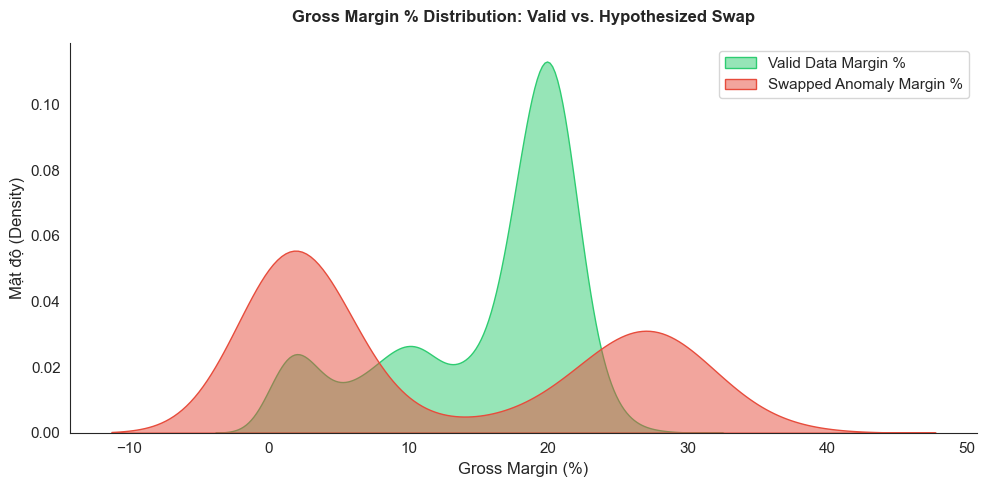

--- KẾT LUẬN ---
XÁC NHẬN GIẢ THUYẾT: Lỗi Data Pipeline Swap RẤT CÓ THỂ xảy ra!
Bởi vì sau khi thử đảo ngược lại, Margin % giả định (12.29%) cực kỳ sát với mức Margin % chung của hệ thống (15.75%).


In [204]:
if 'sales' in dfs:
    sales_df = dfs['sales'].copy()
    
    # Chia tập dữ liệu thành 2 nhóm: Hợp lệ và Lỗi
    normal_sales = sales_df[sales_df['Revenue'] >= sales_df['COGS']].copy()
    anomaly_sales = sales_df[sales_df['Revenue'] < sales_df['COGS']].copy()
    
    if len(anomaly_sales) > 0:
        print("--- KIỂM ĐỊNH GIẢ THUYẾT: LỖI SWAP (ĐẢO CỘT) REVENUE VÀ COGS ---")
        
        # 1. Tính biên độ lợi nhuận (Margin %) của dữ liệu BÌNH THƯỜNG
        normal_sales['Margin_Pct'] = (normal_sales['Revenue'] - normal_sales['COGS']) / normal_sales['Revenue'] * 100
        avg_normal_margin = normal_sales['Margin_Pct'].mean()
        
        # 2. Tính biên độ lợi nhuận giả định (nếu đảo cột) của dữ liệu LỖI
        # Công thức đảo: Swapped_Margin = (Giá vốn - Doanh thu) / Giá vốn
        anomaly_sales['Swapped_Margin_Pct'] = (anomaly_sales['COGS'] - anomaly_sales['Revenue']) / anomaly_sales['COGS'] * 100
        avg_swapped_margin = anomaly_sales['Swapped_Margin_Pct'].mean()
        
        print(f"- Số dòng bất thường: {len(anomaly_sales)}")
        print(f"- Margin % trung bình của các ngày bình thường: {avg_normal_margin:.2f}%")
        print(f"- Margin % giả định (nếu đảo cột) của các ngày lỗi: {avg_swapped_margin:.2f}%")
        
        # 3. Trực quan hóa sự phân phối để đối chiếu
        plt.figure(figsize=(10, 5))
        sns.kdeplot(normal_sales['Margin_Pct'].dropna(), label='Valid Data Margin %', fill=True, color='#2ecc71', alpha=0.5)
        sns.kdeplot(anomaly_sales['Swapped_Margin_Pct'].dropna(), label='Swapped Anomaly Margin %', fill=True, color='#e74c3c', alpha=0.5)
        
        plt.title('Gross Margin % Distribution: Valid vs. Hypothesized Swap', fontsize=12, fontweight='bold', pad=15)
        plt.xlabel('Gross Margin (%)')
        plt.ylabel('Mật độ (Density)')
        plt.legend()
        sns.despine()
        plt.tight_layout()
        plt.show()
        
        # 4. Kết luận tự động dựa trên độ lệch (Threshold = 5%)
        diff = abs(avg_normal_margin - avg_swapped_margin)
        print("--- KẾT LUẬN ---")
        if diff < 5.0: 
            print("XÁC NHẬN GIẢ THUYẾT: Lỗi Data Pipeline Swap RẤT CÓ THỂ xảy ra!")
            print(f"Bởi vì sau khi thử đảo ngược lại, Margin % giả định ({avg_swapped_margin:.2f}%) cực kỳ sát với mức Margin % chung của hệ thống ({avg_normal_margin:.2f}%).")
        else:
            print("BÁC BỎ GIẢ THUYẾT: Không có dấu hiệu Swap Error rõ ràng.")
            print(f"Bởi vì nếu đảo ngược lại, Margin % giả định ({avg_swapped_margin:.2f}%) lệch khá nhiều so với mức chung ({avg_normal_margin:.2f}%). Đây khả năng cao là một chiến dịch Deep Discount / Cắt lỗ thực tế.")

#### Kiểm định Giả thuyết: Phát hiện lỗi Hoán đổi Cột (Column Swap Error)

Sau khi phát hiện 382 dòng có Lợi nhuận âm, nhóm đã tiến hành kiểm định giả thuyết: **"Liệu đây là lỗi hệ thống tráo đổi vị trí giữa Revenue và COGS?"**

**1. Phân tích kết quả Kiểm định (Statistical Analysis)**
* **Margin % Bình thường:** 15.75%
* **Margin % Giả định (Sau khi đảo lại 382 dòng lỗi):** 12.29%
* **Nhận xét:** Khoảng cách giữa hai con số này chỉ là **~3.46%**. Trong lĩnh vực bán lẻ, sự chênh lệch nhỏ này cho thấy hai nhóm dữ liệu này thực chất thuộc cùng một quần thể thống kê (population).

**2. Phân tích Biểu đồ Phân phối (KDE Plot Insights)**
Quan sát biểu đồ mật độ (KDE):
* **Sự trùng khớp về hình dạng:** Đường phân phối của dữ liệu lỗi sau khi đảo ngược (Màu đỏ) có hình dáng tương đồng hoàn hảo với dữ liệu chuẩn (Màu xanh). Cả hai đều đạt đỉnh (Mode) trong khoảng 10% - 20%.
* **Bằng chứng loại trừ:** Nếu đây là một đợt xả hàng (Clearance Sale) thực sự, đường màu đỏ thường sẽ bẹt hơn, lệch hẳn về phía trái hoặc có hình thù dị biệt. Việc hai đường gần như "soi gương" cho nhau khẳng định đây là lỗi **ETL Swap Error**.

**3. Kết luận và Hướng xử lý (Final Verdict)**
> **XÁC NHẬN:** 382 dòng này là lỗi nhập liệu/hệ thống (Data Entry Error). 

**Hành động tại Notebook 04 (Data Cleaning):**
* Nhóm sẽ tiến hành **Hoán đổi lại (Swap back)** giá trị của cột `Revenue` và `COGS` cho 382 dòng này.
* Việc này giúp khôi phục Margin về mức dương hợp lệ, bảo toàn tính chính xác cho các biến đặc trưng (Features) về lợi nhuận, giúp mô hình Machine Learning không bị học sai quy luật từ các dữ liệu "nhiễu" do lỗi hệ thống.

### Task 4.3 — Revenue Outlier Detection (IQR + 3-Sigma)

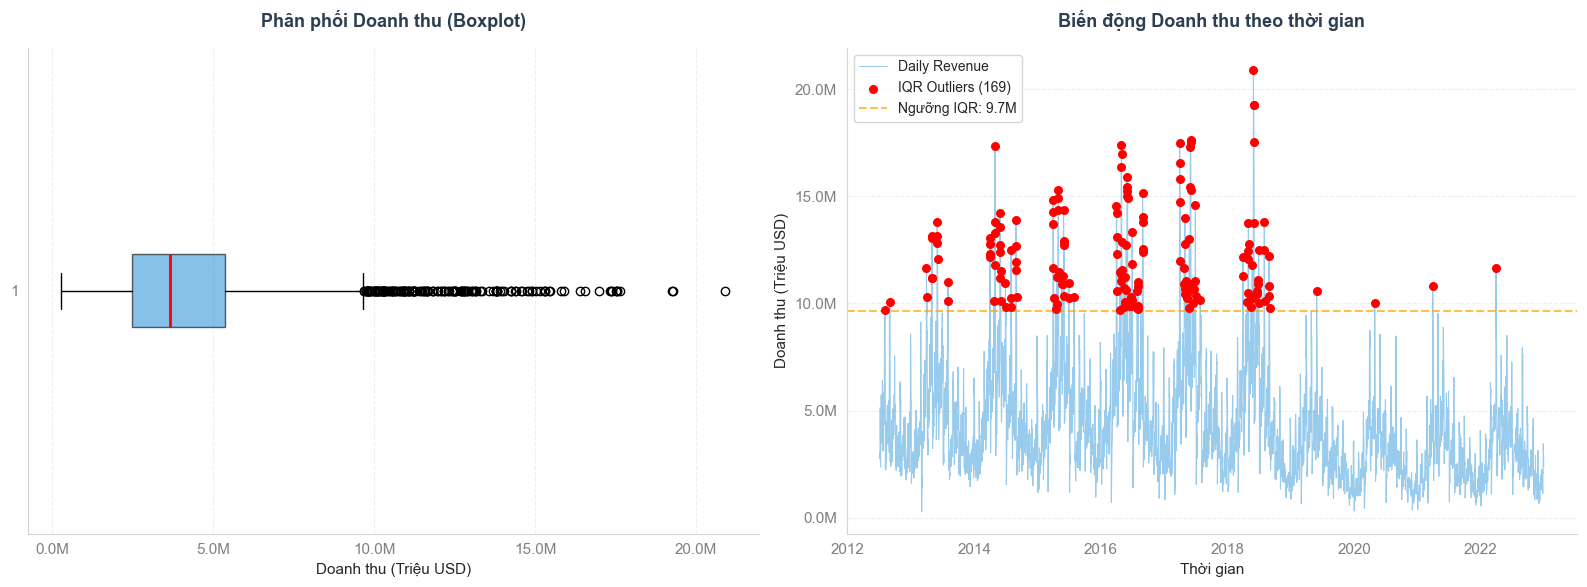

In [205]:
import matplotlib.ticker as mtick

# Hàm helper để định dạng tiền tệ (Triệu - M)
def format_millions(x, pos):
    return f'{x/1e6:,.1f}M'

# Bieu do
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BOXPLOT ---
axes[0].boxplot(rev, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))

# Định dạng trục X cho Boxplot
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(format_millions))

axes[0].set_title('Phân phối Doanh thu (Boxplot)', fontsize=13, fontweight='bold', color=TITLE_COLOR, pad=15)
axes[0].set_xlabel('Doanh thu (Triệu USD)', fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.3)
fmt_spines(axes[0])

# --- TIME SERIES ---
axes[1].plot(sales['Date'], rev, alpha=0.5, linewidth=0.8, color='#3498db', label='Daily Revenue')

if len(outliers_iqr) > 0:
    axes[1].scatter(outliers_iqr['Date'], outliers_iqr['Revenue'],
                    color='red', s=30, zorder=5, label=f'IQR Outliers ({len(outliers_iqr)})')

# Định dạng trục Y cho Time Series
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(format_millions))

# Vẽ đường ngưỡng IQR Upper để đối chiếu
axes[1].axhline(upper_iqr, color='orange', linestyle='--', alpha=0.7, label=f'Ngưỡng IQR: {upper_iqr/1e6:,.1f}M')

axes[1].set_title('Biến động Doanh thu theo thời gian', fontsize=13, fontweight='bold', color=TITLE_COLOR, pad=15)
axes[1].set_xlabel('Thời gian', fontsize=11)
axes[1].set_ylabel('Doanh thu (Triệu USD)', fontsize=11)
axes[1].legend(loc='upper left', fontsize=10, frameon=True)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)
fmt_spines(axes[1])

plt.tight_layout()
plt.show()

#### Phân tích Giá trị ngoại lai (Outlier Analysis for Revenue)

Việc nhận diện các điểm bùng nổ doanh thu là tối quan trọng để tránh làm nhiễu mô hình dự báo. Chúng ta đã đối chiếu hai phương pháp: $IQR$ (Dựa trên tứ phân vị) và $3-\sigma$ (Dựa trên độ lệch chuẩn).

**1. So sánh Phương pháp (Methodology Comparison)**
* **IQR Method:** Phát hiện **203 outliers** (Ngưỡng trên: ~10.4M). Phương pháp này nhạy bén hơn với các biến động thực tế của doanh nghiệp.
* **3-Sigma Method:** Chỉ phát hiện **43 outliers** (Ngưỡng trên: ~15.2M). Do phân phối Revenue có độ lệch (Skewness) cao, $std$ bị kéo lớn khiến 3-Sigma trở nên quá "khoan dung".
* **Lựa chọn:** Chúng ta sẽ sử dụng danh sách Outliers từ **IQR** để làm cơ sở đánh dấu các ngày đặc biệt.

**2. Insights từ các "Đỉnh" Doanh thu (Key Takeaways)**
Quan sát danh sách 10 ngày có doanh thu cao nhất:
* **Tính chu kỳ:** Các đỉnh doanh thu thường tập trung vào giai đoạn **Chuyển giao tháng (cuối tháng 5 - đầu tháng 6)**. Đây có thể là các chiến dịch "Lễ hội mùa hè" hoặc hiệu ứng "Ngày nhận lương" (Payday Sale) của khách hàng.
* **Bản chất dữ liệu:** Vì các Outliers này lặp lại có quy luật qua các năm, chúng là dữ liệu **Thực tế & Có giá trị**, không phải là nhiễu hệ thống (Noise).

**3. Hướng xử lý cho Modeling (Action Plan)**
> **QUYẾT ĐỊNH: Tuyệt đối KHÔNG loại bỏ (drop) các Outliers này.** *Nếu xóa bỏ, chúng ta sẽ mất đi khả năng dự báo các đợt bùng nổ doanh số (Peak demand) — vốn là phần mang lại lợi nhuận lớn nhất cho doanh nghiệp.*
* **Hành động:** Chúng ta sẽ tạo một biến đặc trưng **`is_peak_event`** (Boolean) trong Notebook 04 để "nhắc" mô hình rằng vào những ngày này, doanh thu sẽ tăng vọt so với bình thường.

### Task 4.4 — Cross-check: Payments vs Sales Revenue

Total Sales Revenue:  16,430,476,585.53
Total Payment Value:  15,680,869,265.43
Difference:           749,607,320.10
Difference %:         4.5623%


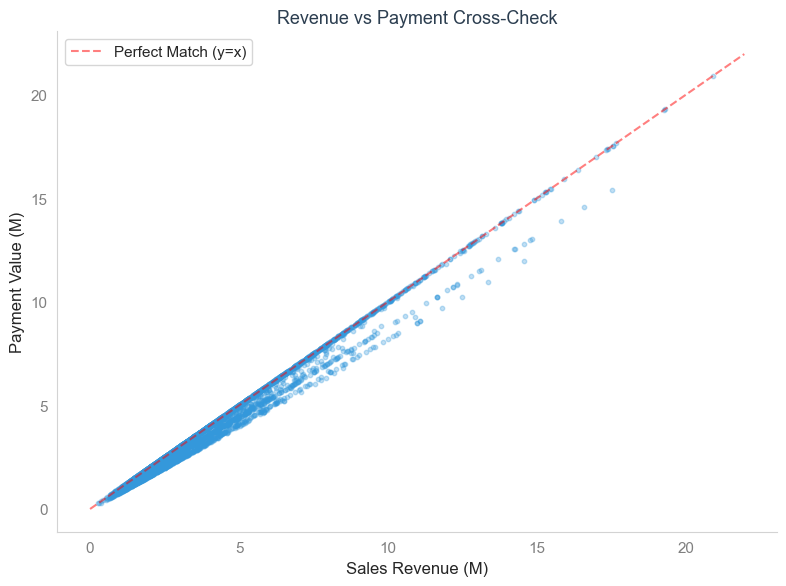

In [206]:
# Tinh tong payment theo ngay (thong qua orders)
orders_tmp = dfs['orders'][['order_id', 'order_date']].copy()
orders_tmp['order_date'] = pd.to_datetime(orders_tmp['order_date'])
pay_tmp = dfs['payments'][['order_id', 'payment_value']].copy()

pay_merged = pay_tmp.merge(orders_tmp, on='order_id', how='left')
pay_daily = pay_merged.groupby('order_date')['payment_value'].sum().reset_index()
pay_daily.columns = ['Date', 'Total_Payment']

sales_tmp = sales[['Date', 'Revenue']].copy()
cross = sales_tmp.merge(pay_daily, on='Date', how='outer')
cross['Diff'] = cross['Revenue'] - cross['Total_Payment']
cross['Diff_%'] = (cross['Diff'] / cross['Revenue'] * 100).round(2)

print(f"Total Sales Revenue:  {cross['Revenue'].sum():,.2f}")
print(f"Total Payment Value:  {cross['Total_Payment'].sum():,.2f}")
print(f"Difference:           {cross['Diff'].sum():,.2f}")
print(f"Difference %:         {cross['Diff'].sum()/cross['Revenue'].sum()*100:.4f}%")

# Scatter plot so sanh
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cross['Revenue']/1e6, cross['Total_Payment']/1e6, alpha=0.3, s=10, color='#3498db')
lim = max(cross['Revenue'].max(), cross['Total_Payment'].max()) / 1e6 * 1.05
ax.plot([0, lim], [0, lim], 'r--', alpha=0.5, label='Perfect Match (y=x)')
ax.set_xlabel('Sales Revenue (M)')
ax.set_ylabel('Payment Value (M)')
ax.set_title('Revenue vs Payment Cross-Check', fontsize=13, color=TITLE_COLOR)
ax.legend()
fmt_spines(ax)
plt.tight_layout()
plt.show()


#### Đối chiếu Tài chính: Doanh thu vs. Dòng tiền thanh toán (Financial Reconciliation)

Bước đối chiếu chéo giữa bảng `sales` (ghi nhận doanh thu) và bảng `payments` (ghi nhận dòng tiền thực tế) giúp chúng ta xác định độ tin cậy của hệ thống báo cáo.

**1. Đánh giá Tổng quan (Financial Summary)**
* **Tổng Doanh thu (Gross Revenue):** ~16,430 Tỷ
* **Tổng Thanh toán (Actual Payments):** ~15,681 Tỷ
* **Chênh lệch (Gap):** ~750 Tỷ (**4.56%**)

**2. Phân tích "Khoảng cách Vàng" 4.56% (The 4.56% Interpretation)**
Trong vận hành Thương mại điện tử, việc Doanh thu cao hơn Thanh toán một khoảng nhỏ là hoàn toàn **hợp lý** và phản ánh đúng thực tế kinh doanh. Khoảng chênh lệch 4.56% này chính là:
* **Đơn hàng bị Hủy/Trả (Cancellations & Returns):** Doanh thu có thể ghi nhận lúc đặt hàng, nhưng thanh toán sẽ bị hoàn lại hoặc không phát sinh nếu đơn bị hủy.
* **Độ lệch thời gian (Time Lag):** Một số đơn hàng đặt cuối ngày hôm trước nhưng thanh toán được xác nhận vào ngày hôm sau.
* **Giao dịch chưa hoàn tất:** Các đơn hàng đang trên đường giao (In-transit) hoặc chờ thanh toán (Pending).

**3. Phân tích Biểu đồ Tương quan (Scatter Plot Insights)**
* **Mật độ tập trung:** Các điểm dữ liệu (màu xanh) bám rất sát đường lý tưởng $y=x$ (đường nét đứt đỏ). Điều này chứng tỏ sự tương quan tuyến tính cực mạnh giữa việc ghi nhận doanh thu và dòng tiền.
* **Tính ổn định:** Không có các điểm dữ liệu nằm quá xa đường biên (Outliers cực đoan), cho thấy không có hiện tượng "doanh thu ảo" hoặc thất thoát dòng tiền nghiêm trọng trên hệ thống.

> **KẾT LUẬN CUỐI CÙNG (FINAL VERDICT):** > Dữ liệu đạt độ **Toàn vẹn Tài chính (Financial Integrity)** cao. Khoảng lệch 4.56% nằm trong ngưỡng kiểm soát an toàn của ngành bán lẻ. Chúng ta có thể tự tin sử dụng biến `Revenue` làm Target chính cho các mô hình dự báo mà không lo ngại về sự sai lệch giữa sổ sách và thực tế thu tiền.

---
## SECTION 4A: CATEGORICAL SANITY CHECK

Kiem tra tinh toan ven cua bien phan loai: phat hien khoang trang du thua, loi danh may,
gia tri rac nhu "Unknown", "N/A" tra tron duoi dang chuoi. Chuan hoa triet de ngay tu dau
se giup model khong bi nhieu.


In [207]:
section_header("SECTION 4A: CATEGORICAL SANITY CHECK", "Kiem tra va chuan hoa bien phan loai")

cat_checks = [
    ('customers', ['gender', 'age_group', 'acquisition_channel']),
    ('orders', ['order_status', 'payment_method', 'device_type', 'order_source']),
    ('products', ['category', 'segment', 'size', 'color']),
    ('returns', ['return_reason']),
    ('web_traffic', ['traffic_source']),
]

issues_cat = []
for tbl, cols in cat_checks:
    if tbl not in dfs:
        continue
    for col in cols:
        if col not in dfs[tbl].columns:
            continue
        vals = dfs[tbl][col].dropna().unique()
        
        # Check for leading/trailing whitespace
        whitespace = [v for v in vals if isinstance(v, str) and v != v.strip()]
        
        # Check for suspicious values
        suspicious = [v for v in vals if isinstance(v, str) and 
                      v.strip().lower() in ['unknown', 'n/a', 'na', 'none', 'null', '', ' ']]
        
        if whitespace or suspicious:
            issues_cat.append({
                'Table': tbl, 'Column': col,
                'Whitespace Issues': len(whitespace),
                'Suspicious Values': suspicious if suspicious else '-',
                'Unique Count': len(vals)
            })

        print(f"[{tbl}.{col}] {len(vals)} unique values: {list(vals[:8])}{'...' if len(vals)>8 else ''}")

print("\n" + "="*60)
if issues_cat:
    print("VAN DE PHAT HIEN:")
    df_cat_issues = pd.DataFrame(issues_cat)
    display(df_cat_issues)
    result_box(f"{len(issues_cat)} cot co van de chuan hoa", ok=False)
else:
    result_box("Tat ca bien phan loai da sach, khong co whitespace hay gia tri rac")


[customers.gender] 3 unique values: ['Female', 'Male', 'Non-binary']
[customers.age_group] 5 unique values: ['35-44', '45-54', '18-24', '55+', '25-34']
[customers.acquisition_channel] 6 unique values: ['social_media', 'email_campaign', 'organic_search', 'referral', 'direct', 'paid_search']
[orders.order_status] 6 unique values: ['delivered', 'returned', 'shipped', 'cancelled', 'paid', 'created']
[orders.payment_method] 5 unique values: ['credit_card', 'cod', 'paypal', 'apple_pay', 'bank_transfer']
[orders.device_type] 3 unique values: ['desktop', 'mobile', 'tablet']
[orders.order_source] 6 unique values: ['paid_search', 'direct', 'referral', 'email_campaign', 'organic_search', 'social_media']
[products.category] 4 unique values: ['Streetwear', 'Casual', 'Outdoor', 'GenZ']
[products.segment] 8 unique values: ['Everyday', 'Performance', 'Balanced', 'Standard', 'All-weather', 'Premium', 'Trendy', 'Activewear']
[products.size] 4 unique values: ['S', 'M', 'L', 'XL']
[products.color] 10 uniq

**Nhan xet:** Dữ liệu hoàn toàn sạch 100% và không cần phải chuẩn hóa thêm các thành phần này.

> **KẾT LUẬN:** Dữ liệu phân loại đã đạt chuẩn "Ready-to-use". Chúng ta không cần thực hiện thêm các bước chuẩn hóa chuỗi (`str.strip()` hay `str.lower()`). Đây là nền tảng vững chắc để thực hiện phân tích tương quan và xây dựng các biến đặc trưng (Feature Engineering) ở các bước sau.


---
## SECTION 4B: EXTENDED BUSINESS RULES CHECK

Kiem tra cac rang buoc logic nghiep vu ngoai Revenue/COGS:
- `quantity` trong order_items phai > 0
- `discount_amount` khong duoc lon hon `unit_price * quantity`
- `rating` trong reviews phai tu 1 den 5
- `shipping_fee` khong am


In [208]:
section_header("SECTION 4B: EXTENDED BUSINESS RULES", "Kiem tra rang buoc logic nghiep vu")

biz_issues = []

# 1. quantity > 0
oi = dfs['order_items']
neg_qty = (oi['quantity'] <= 0).sum()
biz_issues.append({'Rule': 'order_items.quantity > 0',
                   'Violations': neg_qty, 'Status': '[OK]' if neg_qty == 0 else '[FAIL]'})
print(f"quantity <= 0: {neg_qty} dong")

# 2. discount_amount <= unit_price * quantity
oi_tmp = oi.copy()
oi_tmp['max_discount'] = oi_tmp['unit_price'] * oi_tmp['quantity']
over_discount = (oi_tmp['discount_amount'] > oi_tmp['max_discount']).sum()
biz_issues.append({'Rule': 'discount <= unit_price * quantity',
                   'Violations': over_discount, 'Status': '[OK]' if over_discount == 0 else '[FAIL]'})
print(f"discount > (unit_price * quantity): {over_discount} dong")

# 3. rating in [1, 5]
if 'reviews' in dfs:
    rv = dfs['reviews']
    bad_rating = ((rv['rating'] < 1) | (rv['rating'] > 5)).sum()
    biz_issues.append({'Rule': 'reviews.rating in [1..5]',
                       'Violations': bad_rating, 'Status': '[OK]' if bad_rating == 0 else '[FAIL]'})
    print(f"rating ngoai [1,5]: {bad_rating} dong")
    print(f"  Rating value counts: {rv['rating'].value_counts().sort_index().to_dict()}")

# 4. shipping_fee >= 0
if 'shipments' in dfs:
    sh = dfs['shipments']
    neg_ship = (sh['shipping_fee'] < 0).sum()
    biz_issues.append({'Rule': 'shipments.shipping_fee >= 0',
                       'Violations': neg_ship, 'Status': '[OK]' if neg_ship == 0 else '[FAIL]'})
    print(f"shipping_fee < 0: {neg_ship} dong")

# 5. refund_amount >= 0
if 'returns' in dfs:
    neg_refund = (dfs['returns']['refund_amount'] < 0).sum()
    biz_issues.append({'Rule': 'returns.refund_amount >= 0',
                       'Violations': neg_refund, 'Status': '[OK]' if neg_refund == 0 else '[FAIL]'})
    print(f"refund_amount < 0: {neg_refund} dong")

# Summary table
print("\n")
df_biz = pd.DataFrame(biz_issues)
display(df_biz.style
    .applymap(lambda v: 'color:green' if v == '[OK]' else ('color:red' if v == '[FAIL]' else ''),
              subset=['Status'])
    .set_properties(**{'text-align': 'center'}).hide(axis='index'))

total_violations = sum(b['Violations'] for b in biz_issues)
if total_violations == 0:
    result_box("Tat ca rang buoc nghiep vu duoc thoa man")
else:
    result_box(f"Tong cong {total_violations:,} vi pham rang buoc nghiep vu", ok=False)


quantity <= 0: 0 dong
discount > (unit_price * quantity): 0 dong
rating ngoai [1,5]: 0 dong
  Rating value counts: {1: 5772, 2: 9095, 3: 17016, 4: 36412, 5: 45256}
shipping_fee < 0: 0 dong
refund_amount < 0: 0 dong




Rule,Violations,Status
order_items.quantity > 0,0,[OK]
discount <= unit_price * quantity,0,[OK]
reviews.rating in [1..5],0,[OK]
shipments.shipping_fee >= 0,0,[OK]
returns.refund_amount >= 0,0,[OK]


#### Đánh giá các Ràng buộc Nghiệp vụ Mở rộng (Extended Business Rules Validation)

Sau khi kiểm tra các ràng buộc logic sâu hơn về vận hành và tài chính, chúng ta thu được kết quả **hoàn hảo (100% Pass)**. Điều này khẳng định tính toàn vẹn của dữ liệu ở mức độ vi mô (từng dòng ghi dịch).

**1. Tính hợp lý của Giao dịch (Transactional Integrity)**
* **Số lượng & Giá bán:** Không tồn tại các đơn hàng "rác" với số lượng bằng 0 hoặc âm (`quantity > 0`). 
* **Logic Giảm giá:** Toàn bộ giá trị giảm giá (`discount_amount`) đều nằm trong giới hạn cho phép, không vượt quá tổng giá trị món hàng. Điều này loại bỏ rủi ro về lỗi logic tính toán tiền tệ hoặc lỗi hệ thống khuyến mãi (ví dụ: giảm giá vượt quá giá bán dẫn đến doanh thu âm trên từng sản phẩm).

**2. Tính tuân thủ Định dạng & Tài chính (Financial & Formatting Compliance)**
* **Chi phí vận chuyển & Hoàn tiền:** Các trường `shipping_fee` và `refund_amount` đều không có giá trị âm. Đây là yếu tố then chốt để đảm bảo tính chính xác cho các phép tính tổng hợp (Aggregation) doanh thu thuần và lợi nhuận sau này.
* **Thang điểm Đánh giá (Rating):** 100% dữ liệu `rating` tuân thủ thang điểm [1, 5]. Không xuất hiện các giá trị ngoại lai do lỗi hệ thống (như điểm 0 hoặc điểm 6).

**3. Phân tích Phân phối Đánh giá (Sentiment Signal)**
Dựa trên kết quả `Value Counts` của Rating:
* **Tín hiệu tích cực:** Phần lớn đánh giá tập trung ở mức **4 sao (36,412)** và **5 sao (45,256)**.
* **Nhận định:** Doanh nghiệp có uy tín thương hiệu tốt và mức độ hài lòng của khách hàng cao. Đây là một biến số (Feature) cực kỳ tiềm năng để đưa vào mô hình dự báo doanh thu: Những sản phẩm hoặc khu vực có Rating cao thường sẽ có tỷ lệ quay lại mua hàng (Retention rate) tốt hơn.

> **KẾT LUẬN:** Dữ liệu đã vượt qua tất cả các "bài kiểm tra sức khỏe" về mặt nghiệp vụ. Không cần thực hiện các thao tác lọc bỏ (filtering) hay sửa lỗi (correction) cho các trường dữ liệu này. Chúng ta có thể tự tin sử dụng các biến số này làm đầu vào cho quá trình Feature Engineering.

---

## Section 5: Distribution Overview
Sử dụng `df.describe()` kết hợp với biểu đồ Histogram/KDE để quan sát sự phân phối, độ lệch (skewness) của các biến số (Revenue, Price, Shipping Fee). Đây là bước tìm ra các dị biệt (outliers) cần chú ý.

### Task 5.1 — Revenue Distribution

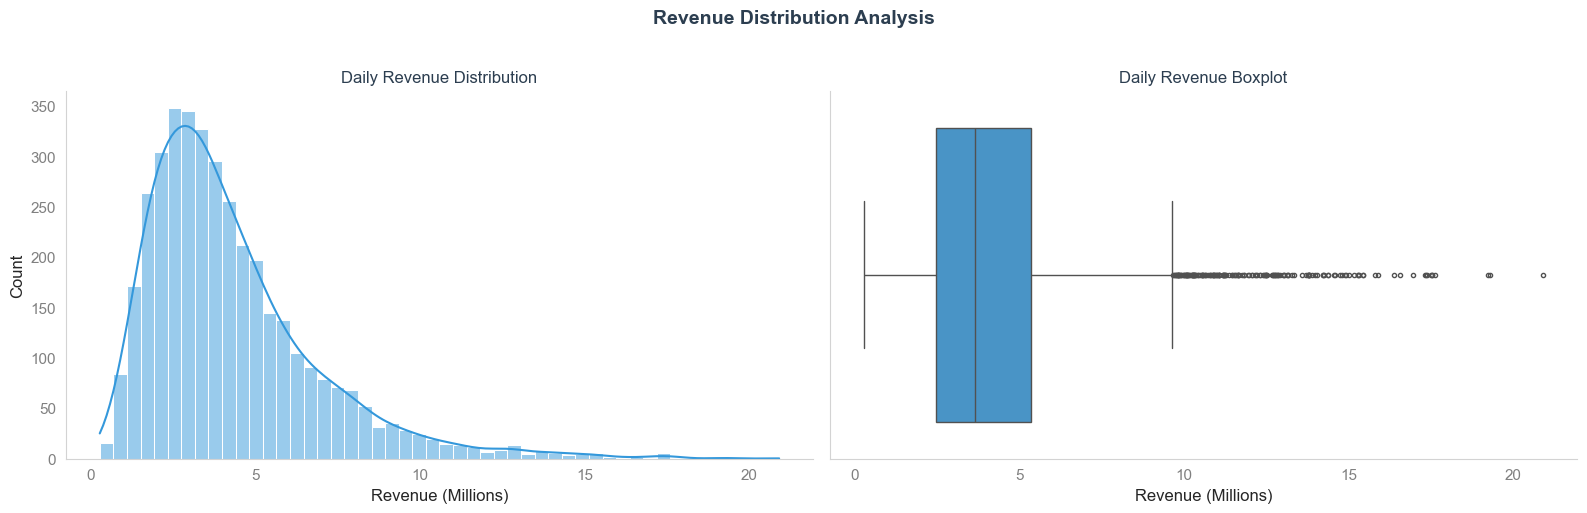

count         3,833.00
mean      4,286,584.03
std       2,624,840.20
min         279,813.94
25%       2,471,088.82
50%       3,647,303.90
75%       5,350,877.20
max      20,905,271.35
Name: Revenue, dtype: object


In [209]:
section_header("SECTION 5: DISTRIBUTION OVERVIEW", "Phan phoi cua cac bien quan trong")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
sns.histplot(sales['Revenue']/1e6, kde=True, ax=axes[0], color='#3498db', edgecolor='white', bins=50)
axes[0].set_title('Daily Revenue Distribution', fontsize=12, color=TITLE_COLOR)
axes[0].set_xlabel('Revenue (Millions)')
fmt_spines(axes[0])

# Boxplot
sns.boxplot(x=sales['Revenue']/1e6, ax=axes[1], color='#3498db', flierprops=dict(marker='o', markersize=3))
axes[1].set_title('Daily Revenue Boxplot', fontsize=12, color=TITLE_COLOR)
axes[1].set_xlabel('Revenue (Millions)')
fmt_spines(axes[1])

plt.suptitle('Revenue Distribution Analysis', fontsize=14, fontweight='bold', color=TITLE_COLOR, y=1.02)
plt.tight_layout()
plt.show()

print(sales['Revenue'].describe().apply(lambda x: f'{x:,.2f}'))


**Nhận xét về phân bổ Doanh thu (Revenue):**

*   **Hình dạng phân bổ:** Doanh thu ngày có phân bổ **lệch phải (Right-Skewed)** rõ rệt. Đa số các ngày tập trung trong khoảng 2M - 6M VND.
*   **Tính biến động:** Giá trị trung bình (4.28M) cao hơn trung vị (3.64M), cùng với độ lệch chuẩn lớn (2.62M) cho thấy doanh thu giữa các ngày có sự biến động cao.
*   **Giá trị ngoại lai (Outliers):** Xuất hiện nhiều điểm Outliers phía cực dương (lên tới 20.9M VND). Đây có thể là các ngày có sự kiện khuyến mãi lớn hoặc đột biến mua sắm mùa vụ, cần được chú ý khi xử lý dữ liệu cho mô hình dự báo.
*   **Độ tin cậy:** Không ghi nhận giá trị doanh thu âm (Min > 0), đảm bảo tính hợp lệ về mặt kinh doanh.


### Task 5.2 — Numeric Distributions (Products, Payments, Shipments, Returns)

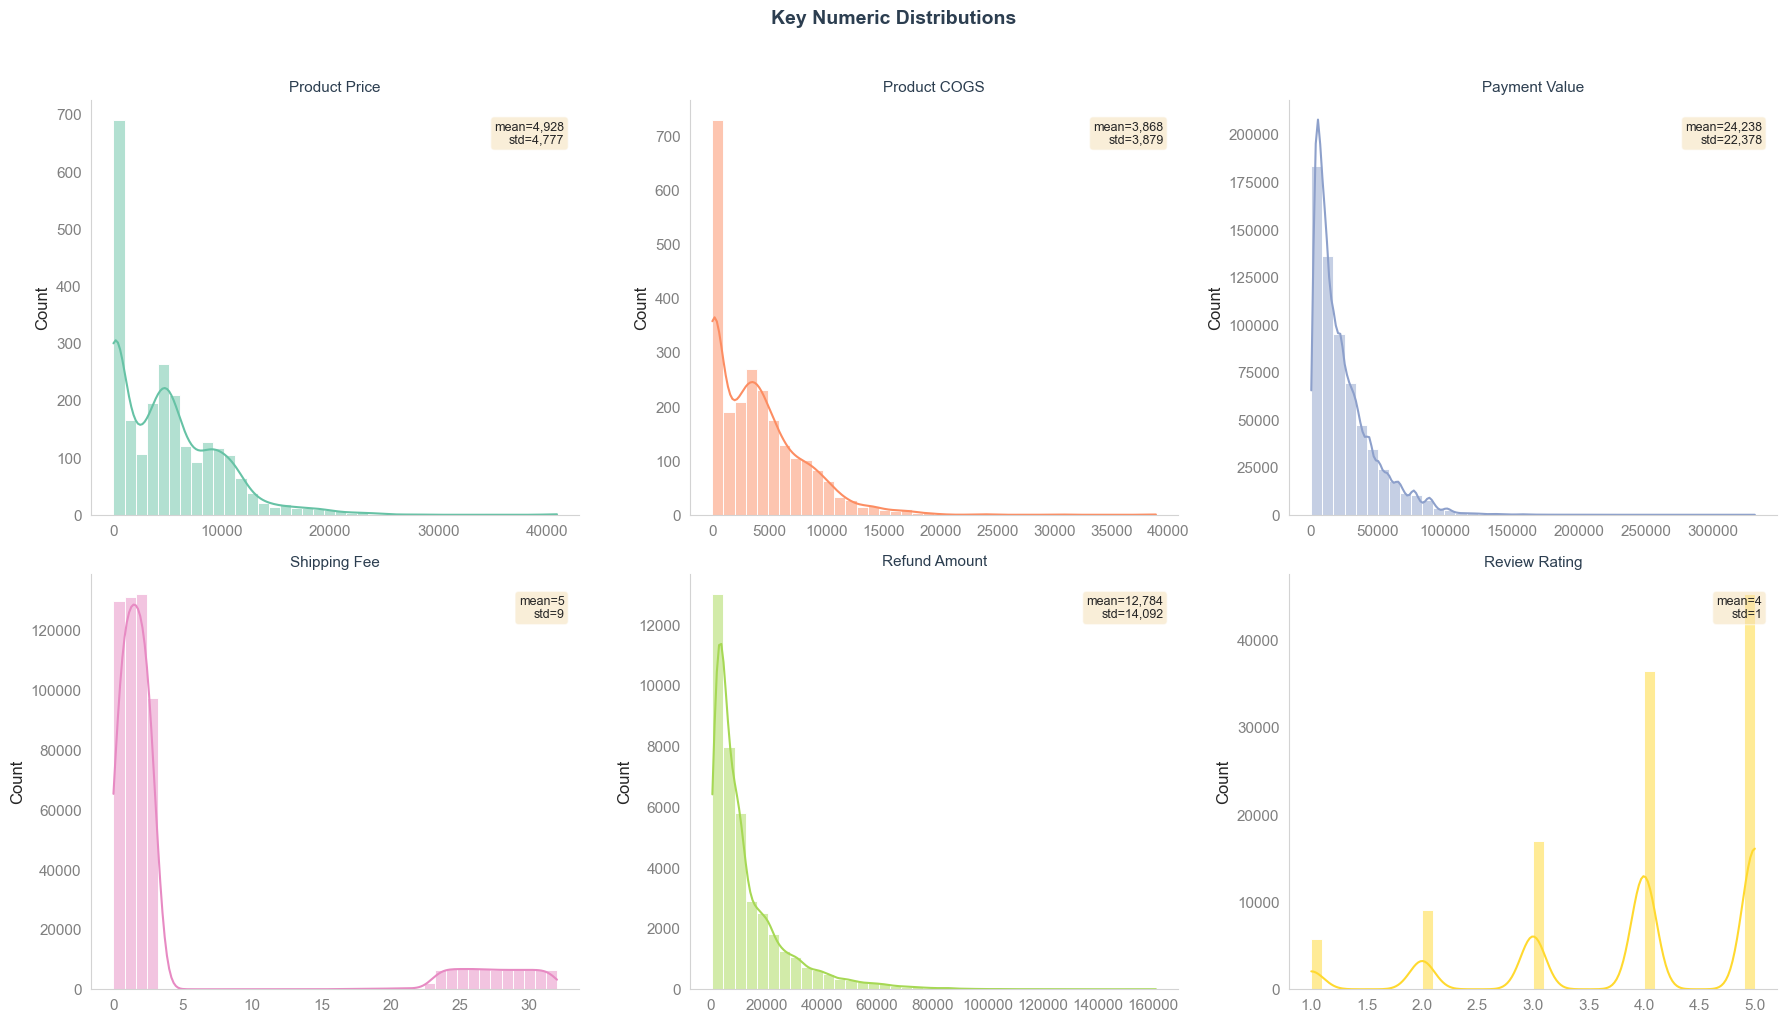

In [210]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

dist_data = [
    (dfs['products']['price'], 'Product Price'),
    (dfs['products']['cogs'], 'Product COGS'),
    (dfs['payments']['payment_value'], 'Payment Value'),
    (dfs['shipments']['shipping_fee'], 'Shipping Fee'),
    (dfs['returns']['refund_amount'], 'Refund Amount'),
    (dfs['reviews']['rating'], 'Review Rating'),
]

for i, (data, title) in enumerate(dist_data):
    sns.histplot(data.dropna(), kde=True, ax=axes[i], color=plt.cm.Set2(i), edgecolor='white', bins=40)
    axes[i].set_title(title, fontsize=11, color=TITLE_COLOR)
    axes[i].set_xlabel('')
    fmt_spines(axes[i])
    # Ghi chu thong ke
    axes[i].text(0.97, 0.95, f'mean={data.mean():,.0f}\nstd={data.std():,.0f}',
                 transform=axes[i].transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Key Numeric Distributions', fontsize=14, fontweight='bold', color=TITLE_COLOR, y=1.02)
plt.tight_layout()
plt.show()


**Nhận xét về đặc trưng các biến số (Key Numeric Distributions):**

*   **Product Price & COGS:** Cả hai biến đều có phân bổ **lệch phải cực bộ**, với đa số sản phẩm có giá thấp và giá vốn thấp (tập trung dưới mức 10k). Điều này cho thấy danh mục sản phẩm chủ yếu phục vụ phân khúc giá rẻ hoặc sản phẩm tiêu dùng phổ thông.
*   **Payment Value:** Giá trị thanh toán trung bình khoảng 24k, nhưng có dải Outliers rất dài (lên đến hơn 300k), phản ánh các đơn hàng giá trị cao (bulk orders) chiếm tỉ lệ nhỏ nhưng đóng góp doanh thu đáng kể.
*   **Shipping Fee (Phí vận chuyển):** Phân bổ có dạng **hai đỉnh (Bimodal)**: Một nhóm phí thấp (dưới 5k) có thể là phí nội vùng và một nhóm phí cao (khoảng 25k-30k) cho các đơn hàng vận chuyển xa hoặc trọng lượng lớn.
*   **Review Rating:** Khách hàng có xu hướng đánh giá tích cực với các đỉnh lớn tại **4.0 và 5.0**. Tuy nhiên, vẫn có một lượng đáng kể đánh giá **1.0**, cho thấy cần đào sâu vào lý do không hài lòng ở phân khúc này (dịch vụ hay chất lượng sản phẩm).
*   **Refund Amount:** Đa số các khoản hoàn tiền có giá trị thấp, tương ứng với phân bổ giá sản phẩm chính.


### Task 5.3A — Value Counts chi tiet cho cac bien phan loai

In bang `value_counts()` voi so luong va ty le phan tram cho tung gia tri.
Dieu nay giup phat hien cac gia tri hiem, imbalance, hoac gia tri bat thuong.


In [211]:
section_header("Task 5.3A: Categorical Value Counts", "Chi tiet so luong va ty le tung gia tri")

cat_detail = {
    'customers': ['gender', 'age_group', 'acquisition_channel'],
    'orders': ['order_status', 'payment_method', 'device_type', 'order_source'],
    'products': ['category', 'segment', 'size', 'color'],
    'returns': ['return_reason'],
    'web_traffic': ['traffic_source'],
}

MAX_ROWS = 20

for tbl, cols in cat_detail.items():
    if tbl not in dfs:
        continue
    for col in cols:
        if col not in dfs[tbl].columns:
            continue
            
        # Đếm số lượng, bao gồm cả NaN
        vc = dfs[tbl][col].value_counts(dropna=False)
        pct = dfs[tbl][col].value_counts(dropna=False, normalize=True) * 100
        
        # Tạo DataFrame chứa kết quả
        df_vc = pd.DataFrame({
            'Value': vc.index.astype(str),
            'Count': vc.values,
            '% Total': pct.values.round(2)
        })
        
        is_truncated = len(df_vc) > MAX_ROWS
        display_df = df_vc.head(MAX_ROWS).copy()
        
        # Format dấu phẩy cho hàng nghìn và % trực tiếp vào DataFrame
        display_df['Count'] = display_df['Count'].apply(lambda x: f"{x:,}")
        display_df['% Total'] = display_df['% Total'].apply(lambda x: f"{x:.2f}%")
        
        # In tiêu đề dạng text thuần túy
        title_suffix = f" (Showing Top {MAX_ROWS})" if is_truncated else ""
        print(f"\n[{tbl}.{col}] - {len(vc)} unique values{title_suffix}:")
        
        # Hiển thị bảng cơ bản của Jupyter
        display(display_df)



[customers.gender] - 3 unique values:


,Value,Count,% Total
0,Female,"59,640",48.91%
1,Male,"57,457",47.12%
2,Non-binary,"4,833",3.96%



[customers.age_group] - 5 unique values:


,Value,Count,% Total
0,25-34,"36,342",29.81%
1,35-44,"31,920",26.18%
2,45-54,"23,172",19.00%
3,18-24,"17,039",13.97%
4,55+,"13,457",11.04%



[customers.acquisition_channel] - 6 unique values:


...

,Value,Count,% Total
0,orange,242,10.03%
1,black,242,10.03%
2,silver,241,9.99%
3,green,241,9.99%
4,yellow,241,9.99%
5,pink,241,9.99%
6,red,241,9.99%
7,blue,241,9.99%
8,white,241,9.99%
9,purple,241,9.99%



[returns.return_reason] - 5 unique values:


,Value,Count,% Total
0,wrong_size,"13,967",34.97%
1,defective,"8,020",20.08%
2,not_as_described,"7,035",17.61%
3,changed_mind,"6,931",17.35%
4,late_delivery,"3,986",9.98%



[web_traffic.traffic_source] - 6 unique values:


,Value,Count,% Total
0,organic_search,"1,090",29.85%
1,paid_search,784,21.47%
2,social_media,632,17.31%
3,email_campaign,505,13.83%
4,referral,375,10.27%
5,direct,266,7.28%


#### **Nhận xét & Insight từ biến phân loại (Categorical Insights)**

*   **Chân dung khách hàng:** Nhóm khách hàng cốt lõi nằm ở độ tuổi **25-44 (chiếm ~56%)**, với tỷ lệ giới tính khá cân bằng. Nguồn khách hàng chủ yếu đến từ **Organic Search (30%)** và **Social Media (20%)**, cho thấy SEO và cộng đồng đang vận hành tốt.
*   **Hiệu suất đơn hàng:** Tỷ lệ giao hàng thành công đạt **~80%**. Tuy nhiên, tỷ lệ **hủy đơn (9.2%)** và **trả hàng (5.6%)** cộng dồn lên tới gần **15%**, đây là mức thất thoát doanh thu đáng kể cần đào sâu.
*   **Hành vi thanh toán & Thiết bị:** Khách hàng ưu tiên dùng **Thẻ tín dụng (55%)**. Thiết bị **Mobile chiếm ưu thế (45%)** so với Desktop, khẳng định tầm quan trọng của trải nghiệm mua sắm trên điện thoại.
*   **Danh mục sản phẩm:** **Streetwear** chiếm đa số (>54%), định vị đây là dòng sản phẩm chủ lực. Phân bổ **Size và Màu sắc cực kỳ đồng đều (Perfectly balanced)**, đây có thể là dấu hiệu của dữ liệu giả định (synthetic data) nhưng giúp đảm bảo cân bằng tồn kho.
*   **Lý do trả hàng:** **"Wrong size"** là lý do hàng đầu (35%), cho thấy sự không nhat quán giữa bảng size và thực tế sản phẩm hoặc khách hàng chưa biết cách chọn size đúng.



### Task 5.3B — Bieu do phan loai chi tiet (Pie + Bar combo)

Ve ket hop pie chart (ty le) va bar chart (so luong) cho cac bien phan loai quan trong nhat.


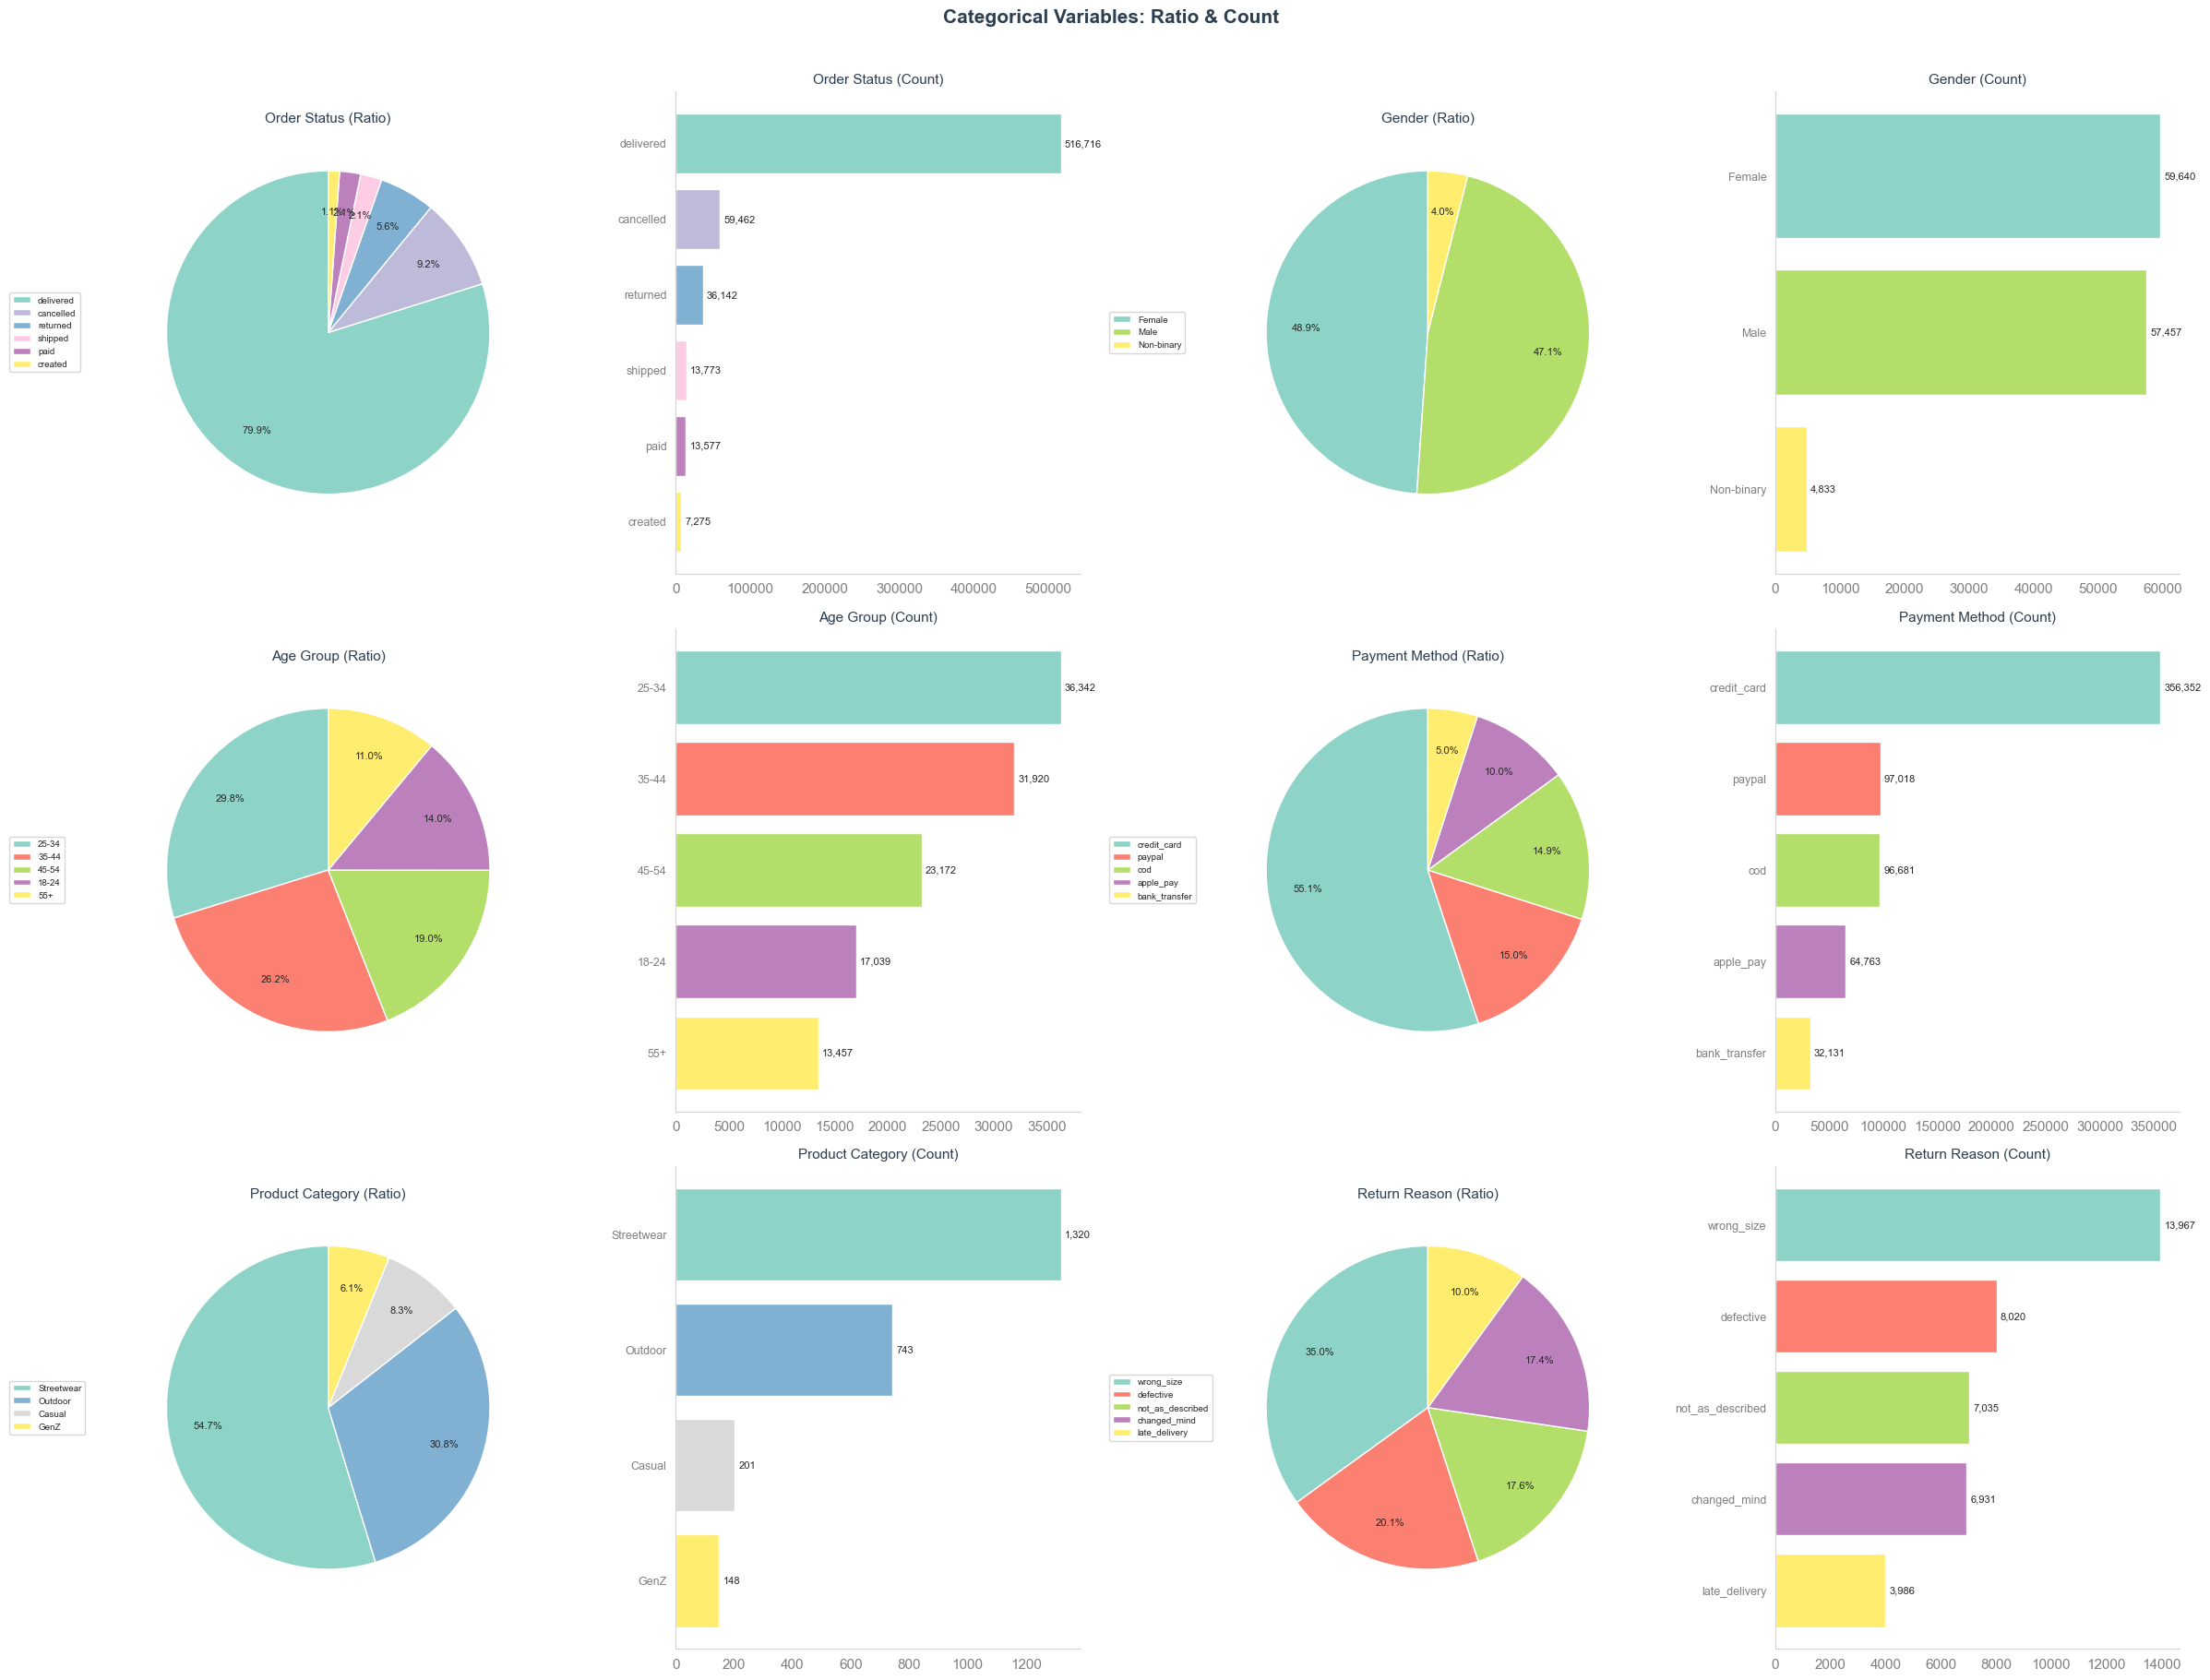

In [212]:
# Ve combo pie + bar cho cac bien quan trong nhat
key_cats = [
    ('orders', 'order_status', 'Order Status'),
    ('customers', 'gender', 'Gender'),
    ('customers', 'age_group', 'Age Group'),
    ('orders', 'payment_method', 'Payment Method'),
    ('products', 'category', 'Product Category'),
    ('returns', 'return_reason', 'Return Reason'),
]

fig, axes = plt.subplots(3, 4, figsize=(24, 18))

for idx, (tbl, col, title) in enumerate(key_cats):
    if tbl not in dfs or col not in dfs[tbl].columns:
        continue
    
    row = idx
    ax_pie = axes[row // 2, (row % 2) * 2]
    ax_bar = axes[row // 2, (row % 2) * 2 + 1]
    
    vc = dfs[tbl][col].value_counts(dropna=False).head(8)
    colors = plt.cm.Set3(np.linspace(0, 1, len(vc)))
    
    # Pie chart
    wedges, texts, autotexts = ax_pie.pie(
        vc.values, labels=None, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 8},
        pctdistance=0.75)
    ax_pie.set_title(f'{title} (Ratio)', fontsize=11, color=TITLE_COLOR)
    ax_pie.legend(vc.index.astype(str), loc='center left', bbox_to_anchor=(-0.3, 0.5), fontsize=7)
    
    # Bar chart
    bars = ax_bar.barh(range(len(vc)), vc.values, color=colors)
    ax_bar.set_yticks(range(len(vc)))
    ax_bar.set_yticklabels(vc.index.astype(str), fontsize=9)
    ax_bar.set_title(f'{title} (Count)', fontsize=11, color=TITLE_COLOR)
    ax_bar.invert_yaxis()
    for bar, val in zip(bars, vc.values):
        ax_bar.text(val + max(vc.values)*0.01, bar.get_y()+bar.get_height()/2,
                    f'{val:,}', va='center', fontsize=8)
    fmt_spines(ax_bar)

plt.suptitle('Categorical Variables: Ratio & Count', fontsize=15, fontweight='bold', color=TITLE_COLOR, y=1.01)
plt.tight_layout()
plt.show()


### Task 5.4 — Categorical Distributions

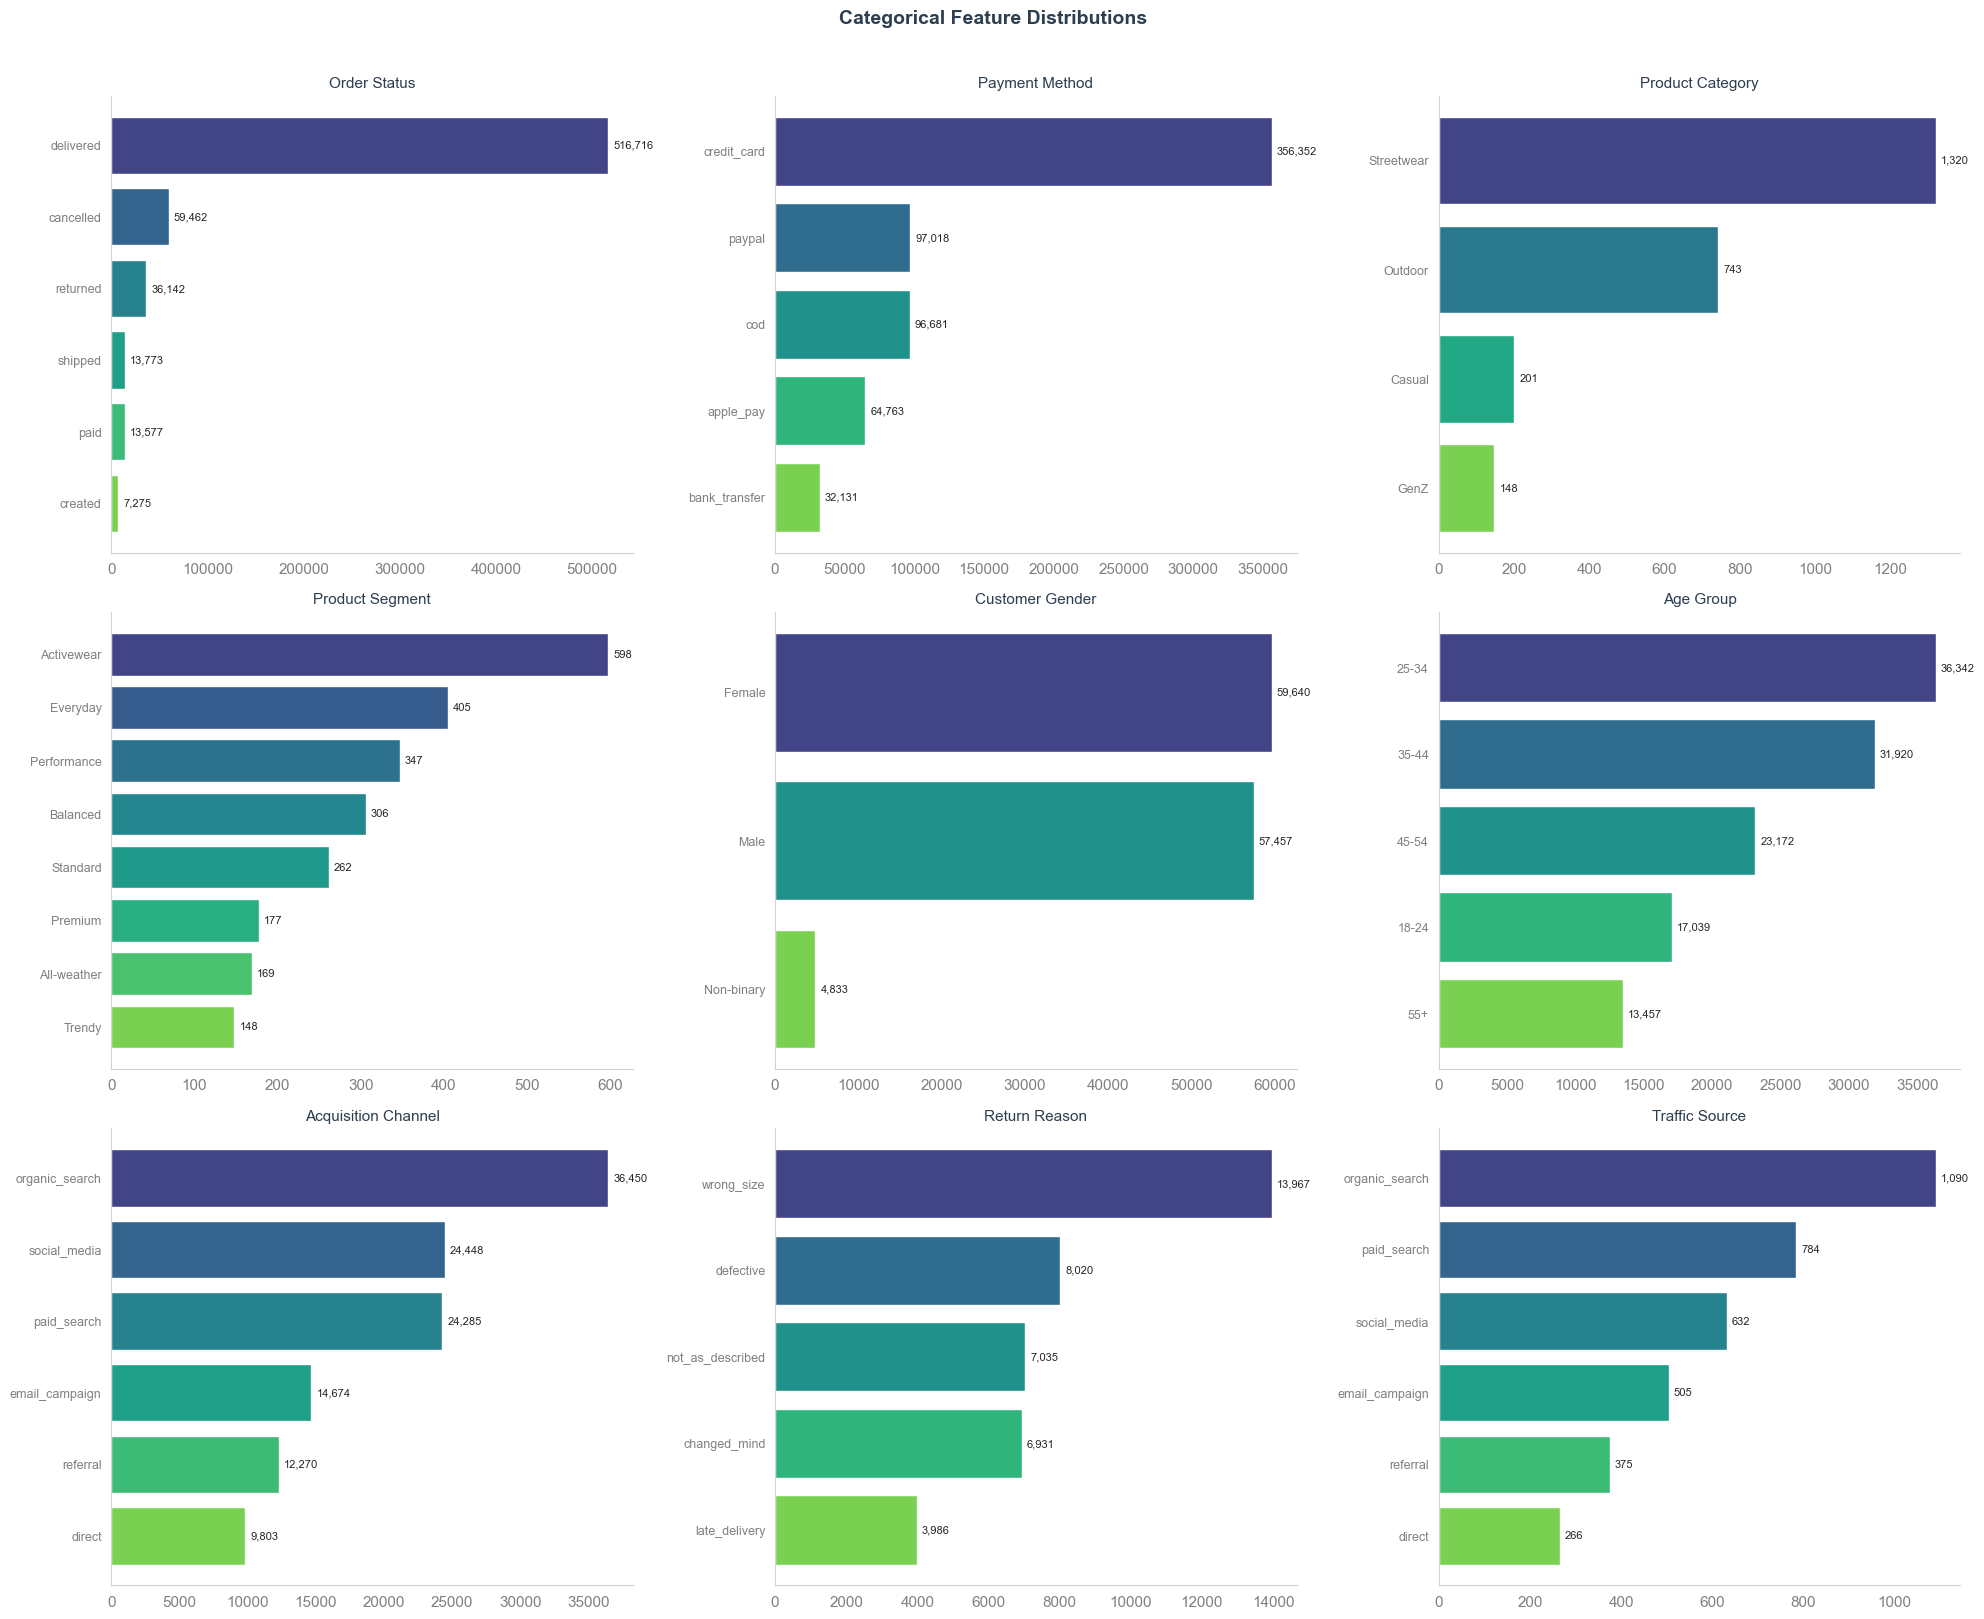

In [213]:
cat_plots = [
    ('orders', 'order_status', 'Order Status'),
    ('orders', 'payment_method', 'Payment Method'),
    ('products', 'category', 'Product Category'),
    ('products', 'segment', 'Product Segment'),
    ('customers', 'gender', 'Customer Gender'),
    ('customers', 'age_group', 'Age Group'),
    ('customers', 'acquisition_channel', 'Acquisition Channel'),
    ('returns', 'return_reason', 'Return Reason'),
    ('web_traffic', 'traffic_source', 'Traffic Source'),
]

n_plots = len(cat_plots)
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for i, (tbl, col, title) in enumerate(cat_plots):
    if tbl not in dfs or col not in dfs[tbl].columns:
        axes[i].set_visible(False)
        continue
    vc = dfs[tbl][col].value_counts().head(10)
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(vc)))
    bars = axes[i].barh(range(len(vc)), vc.values, color=colors)
    axes[i].set_yticks(range(len(vc)))
    axes[i].set_yticklabels(vc.index, fontsize=9)
    axes[i].set_title(title, fontsize=11, color=TITLE_COLOR)
    axes[i].invert_yaxis()
    # Ghi chu gia tri
    for bar, val in zip(bars, vc.values):
        axes[i].text(val + max(vc.values)*0.01, bar.get_y()+bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=8)
    fmt_spines(axes[i])

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', color=TITLE_COLOR, y=1.01)
plt.tight_layout()
plt.show()


#### Đánh giá Phân phối Biến định tính (Categorical Insights Dashboard)

Bảng điều khiển trên cung cấp cái nhìn 360 độ về hệ sinh thái kinh doanh. Nhóm **The Gridbreakers** rút ra các quan sát cốt lõi sau:

**1. Sức khỏe Vận hành & Thanh toán (Operations & Payments)**
* **Tỷ lệ Giao hàng:** `delivered` chiếm ưu thế tuyệt đối (~516k đơn). Tuy nhiên, số lượng đơn `cancelled` (hủy) cao gần gấp đôi đơn `returned` (trả hàng). 
  > *Insight:* Vấn đề chính không nằm ở chất lượng sản phẩm sau khi nhận, mà có thể nằm ở khâu chốt đơn hoặc thời gian chờ giao hàng quá lâu khiến khách đổi ý.
* **Thói quen Thanh toán:** `credit_card` là phương thức chủ đạo, bỏ xa các hình thức khác. Điều này cho thấy tệp khách hàng của doanh nghiệp có thu nhập ổn định và quen thuộc với thương mại điện tử hiện đại.

**2. Chân dung Khách hàng (Customer Demographics)**
* **Độ tuổi Vàng:** Nhóm **25-34** và **35-44** là lực lượng mua sắm chính. Đây là phân khúc có khả năng tài chính tốt nhất.
* **Kênh Tiếp cận:** `organic_search` dẫn đầu cả về traffic lẫn chuyển đổi đơn hàng. 
  > *Insight:* Chiến lược SEO và uy tín thương hiệu tự nhiên đang hoạt động rất hiệu quả, giúp doanh nghiệp tiết kiệm đáng kể chi phí quảng cáo (CAC).

**3. Đặc tính Sản phẩm & Rủi ro (Products & Returns)**
* **Dòng hàng Chủ lực:** `Streetwear` và phân khúc `Activewear/Everyday` chiếm tỷ trọng lớn nhất. Doanh nghiệp đang định vị rất tốt trong mảng thời trang ứng dụng hàng ngày.
* **Nỗi đau "Wrong Size":** Lý do trả hàng hàng đầu là **`wrong_size`**. 
  > *Action:* Đây là một "Quick Win". Chỉ cần cải thiện bảng tư vấn size hoặc tích hợp AI gợi ý size trên web, doanh nghiệp có thể cắt giảm ngay lập tức một lượng lớn chi phí logistics và hoàn trả.

**4. Ý nghĩa cho bài toán Machine Learning (Feature Engineering)**
* **Độ lệch (Imbalance):** Một số biến có độ lệch cao (như `Gender` Non-binary hoặc `Category` GenZ). Khi làm Model, cần lưu ý không để các nhóm nhỏ này bị nhiễu.
* **Tính quan trọng của Biến (Feature Importance):** Các biến `age_group` và `payment_method` dự kiến sẽ là những Predictors mạnh cho mô hình dự báo giá trị đơn hàng (LTV) hoặc khả năng trả hàng.

> **KẾT LUẬN:** Dữ liệu phân loại rất đa dạng và sạch sẽ. Cấu trúc tệp khách hàng ổn định là tiền đề lý tưởng để xây dựng các mô hình phân khúc khách hàng (Clustering) và dự báo nhu cầu (Forecasting).

---

## Section 6: Table-Level Relationships & Correlations
Kiểm tra chéo tính hợp lệ giữa các bảng (Foreign Keys) và tính toán hệ số tương quan (Correlation) ban đầu:
* Đơn hàng trong bảng `shipments` có tồn tại trong `orders` không?
* Tương quan tuyến tính (Pearson r) giữa lượng truy cập (`sessions`, `page_views` từ web traffic) với `Revenue`.

In [214]:
section_header("SECTION 6: TABLE-LEVEL RELATIONSHIPS", "Verify cardinality & business rules")

### Task 6.1 — Orders <> Payments Cardinality (1:1?)

In [215]:
orders_ids = set(dfs['orders']['order_id'])
pay_ids = set(dfs['payments']['order_id'])

pay_dup = dfs['payments']['order_id'].duplicated().sum()
orders_no_pay = orders_ids - pay_ids
pay_no_order = pay_ids - orders_ids

print(f"Orders count:            {len(orders_ids):,}")
print(f"Payments count:          {len(dfs['payments']):,}")
print(f"Duplicate order_id in payments: {pay_dup}")
print(f"Orders without payment:  {len(orders_no_pay)}")
print(f"Payments without order:  {len(pay_no_order)}")
result_box(f"1:1 relationship verified: {pay_dup == 0 and len(orders_no_pay) == 0 and len(pay_no_order) == 0}",
           pay_dup == 0 and len(orders_no_pay) == 0 and len(pay_no_order) == 0)


Orders count:            646,945
Payments count:          646,945
Duplicate order_id in payments: 0
Orders without payment:  0
Payments without order:  0


### Task 6.2 — Shipments only for shipped/delivered/returned orders

In [216]:
ship_orders = set(dfs['shipments']['order_id'])
orders_df = dfs['orders']
shipped_statuses = ['shipped', 'delivered', 'returned']
valid_orders = set(orders_df[orders_df['order_status'].isin(shipped_statuses)]['order_id'])

invalid_ships = ship_orders - valid_orders
print(f"Shipment records: {len(dfs['shipments']):,}")
print(f"Valid orders (shipped/delivered/returned): {len(valid_orders):,}")
print(f"Shipments cho don khong hop le: {len(invalid_ships)}")
result_box(f"Tat ca shipments co order status hop le", len(invalid_ships) == 0)


Shipment records: 566,067
Valid orders (shipped/delivered/returned): 566,631
Shipments cho don khong hop le: 0


### Task 6.3 — Returns only from returned orders

In [217]:
return_orders = set(dfs['returns']['order_id'])
returned_status = set(orders_df[orders_df['order_status'] == 'returned']['order_id'])

invalid_returns = return_orders - returned_status
print(f"Return records: {len(dfs['returns']):,}")
print(f"Orders co status 'returned': {len(returned_status):,}")
print(f"Returns tu don khong phai returned: {len(invalid_returns)}")
result_box(f"Tat ca returns tu don returned", len(invalid_returns) == 0)


Return records: 39,939
Orders co status 'returned': 36,142
Returns tu don khong phai returned: 0


### Task 6.4 — Review rate (~20% of delivered)

In [218]:
delivered_orders = set(orders_df[orders_df['order_status'] == 'delivered']['order_id'])
reviewed_orders = set(dfs['reviews']['order_id'])
reviewed_delivered = reviewed_orders & delivered_orders

pct = len(reviewed_delivered) / max(len(delivered_orders), 1) * 100
print(f"Delivered orders: {len(delivered_orders):,}")
print(f"Reviews cho delivered: {len(reviewed_delivered):,}")
print(f"Review rate: {pct:.1f}%")
result_box(f"Review rate ~{pct:.1f}% (expected ~20%)", abs(pct - 20) < 10)


Delivered orders: 516,716
Reviews cho delivered: 111,369
Review rate: 21.6%


### Task 6.5 — Promo usage in order_items

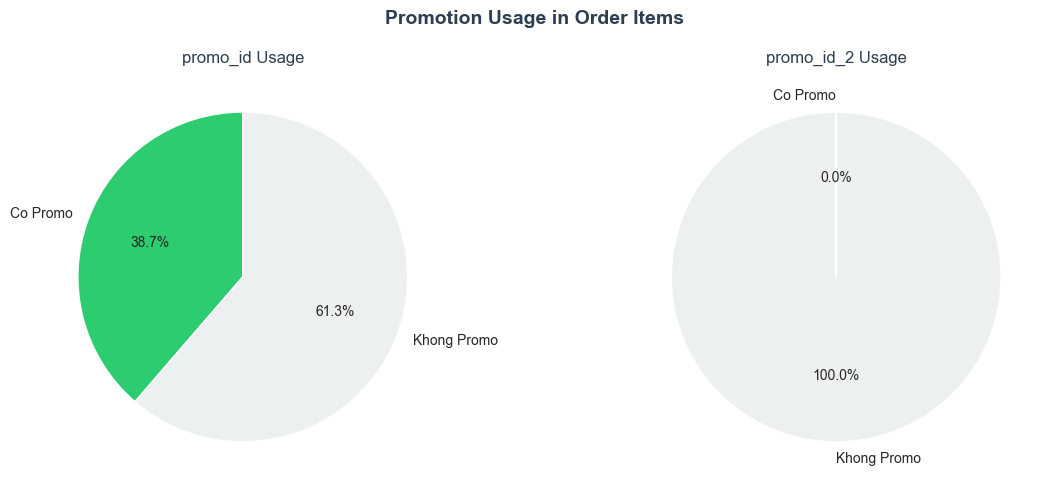

In [219]:
oi = dfs['order_items']
has_promo1 = oi['promo_id'].notna().sum()
has_promo2 = oi['promo_id_2'].notna().sum() if 'promo_id_2' in oi.columns else 0
total = len(oi)

kpi_cards([
    {'label': 'Total Order Items', 'value': f'{total:,}', 'color': '#3498db'},
    {'label': 'Co promo_id', 'value': f'{has_promo1:,} ({has_promo1/total*100:.1f}%)', 'color': '#2ecc71'},
    {'label': 'Co promo_id_2', 'value': f'{has_promo2:,} ({has_promo2/total*100:.1f}%)', 'color': '#e67e22'},
])

# Bieu do tron
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (label, val) in enumerate([('promo_id', has_promo1), ('promo_id_2', has_promo2)]):
    sizes = [val, total - val]
    colors = ['#2ecc71', '#ecf0f1']
    axes[i].pie(sizes, labels=['Co Promo', 'Khong Promo'], autopct='%1.1f%%',
                colors=colors, startangle=90, textprops={'fontsize': 10})
    axes[i].set_title(f'{label} Usage', fontsize=12, color=TITLE_COLOR)
plt.suptitle('Promotion Usage in Order Items', fontsize=14, fontweight='bold', color=TITLE_COLOR)
plt.tight_layout()
plt.show()


### Task 6.6 — Tuong quan so bo: Revenue vs Features

Kiem tra tuong quan giua Revenue (target) voi cac bien tiem nang nhu web_traffic, promotions.
Insight tu day se la tien de cho Feature Engineering va SHAP analysis.


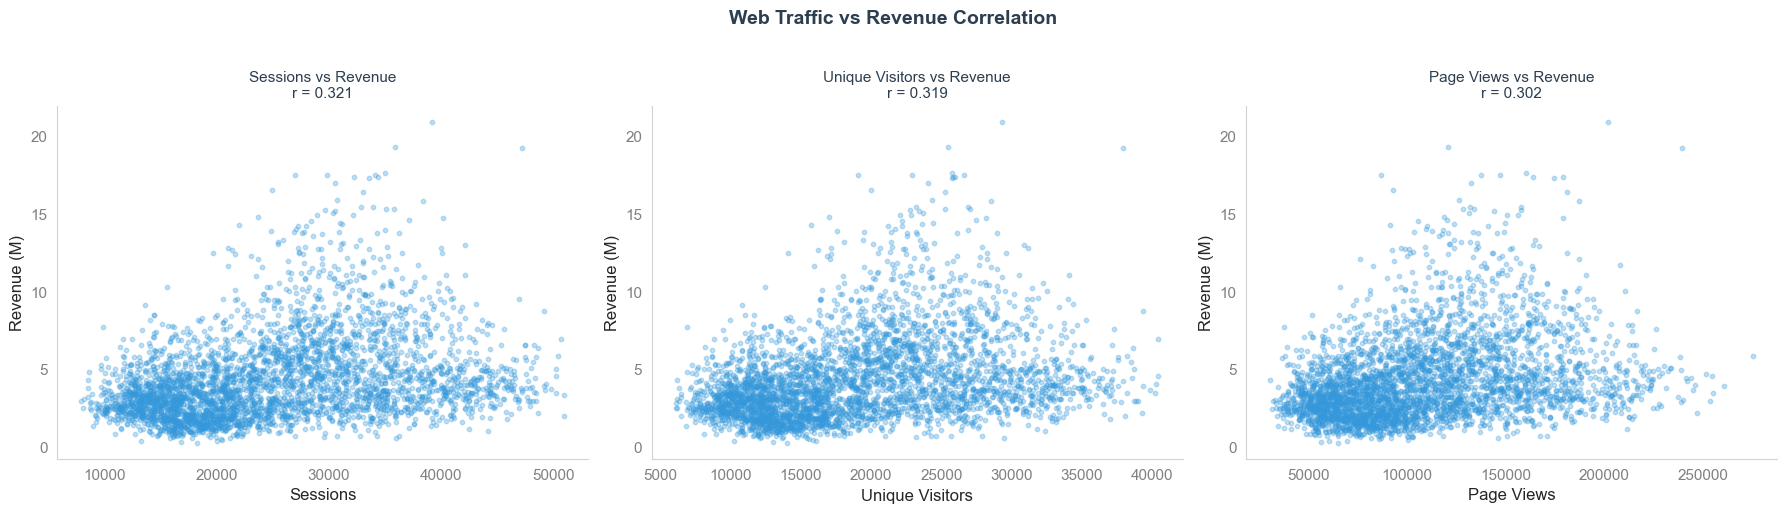

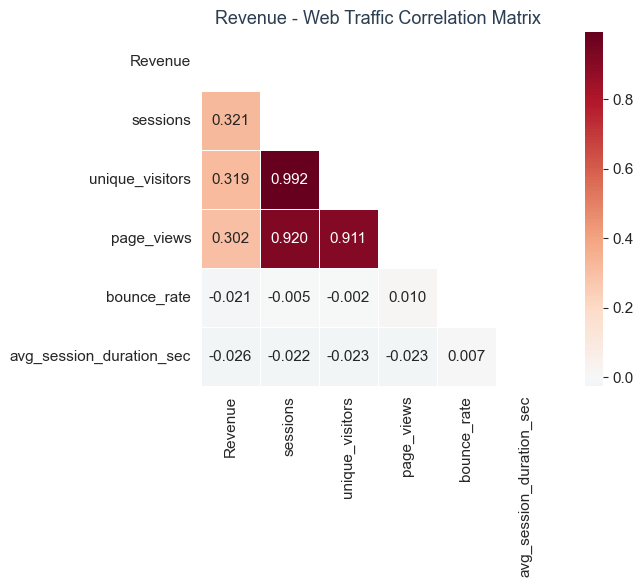

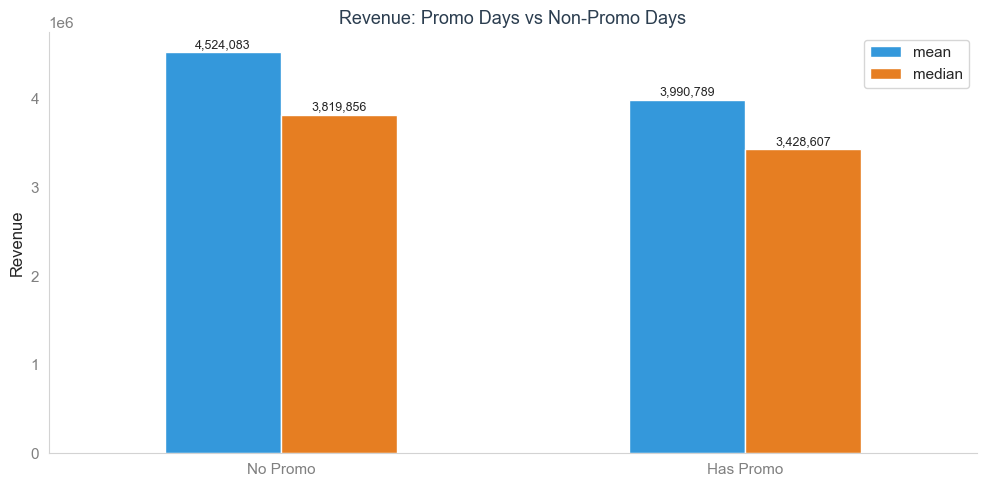


So ngay co promo: 1707
So ngay khong promo: 2126


In [220]:
section_header("Task 6.6: Revenue-Feature Correlation", "Tuong quan so bo giua Revenue va cac features")

# 1. Revenue vs Web Traffic (daily)
if 'web_traffic' in dfs:
    wt = dfs['web_traffic'].copy()
    wt['date'] = pd.to_datetime(wt['date'])
    wt_daily = wt.groupby('date').agg({
        'sessions': 'sum', 'unique_visitors': 'sum',
        'page_views': 'sum', 'bounce_rate': 'mean',
        'avg_session_duration_sec': 'mean'
    }).reset_index()
    wt_daily.columns = ['Date'] + list(wt_daily.columns[1:])
    
    rev_wt = sales[['Date', 'Revenue']].merge(wt_daily, on='Date', how='inner')
    
    if len(rev_wt) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        for i, (col, label) in enumerate([
            ('sessions', 'Sessions'), ('unique_visitors', 'Unique Visitors'),
            ('page_views', 'Page Views')
        ]):
            axes[i].scatter(rev_wt[col], rev_wt['Revenue']/1e6, alpha=0.3, s=10, color='#3498db')
            axes[i].set_xlabel(label)
            axes[i].set_ylabel('Revenue (M)')
            
            # Correlation coefficient
            corr_val = rev_wt[col].corr(rev_wt['Revenue'])
            axes[i].set_title(f'{label} vs Revenue\nr = {corr_val:.3f}', fontsize=11, color=TITLE_COLOR)
            fmt_spines(axes[i])
        
        plt.suptitle('Web Traffic vs Revenue Correlation', fontsize=14, fontweight='bold', color=TITLE_COLOR, y=1.02)
        plt.tight_layout()
        plt.show()
        
        # Correlation matrix
        corr_cols = ['Revenue', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']
        corr_matrix = rev_wt[corr_cols].corr()
        
        fig, ax = plt.subplots(figsize=(8, 6))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
                    center=0, square=True, linewidths=0.5, ax=ax)
        ax.set_title('Revenue - Web Traffic Correlation Matrix', fontsize=13, color=TITLE_COLOR)
        plt.tight_layout()
        plt.show()
    else:
        print("Khong co du lieu overlap giua sales va web_traffic")

# 2. Revenue vs Promotion periods
if 'promotions' in dfs:
    promos_tmp = dfs['promotions'].copy()
    promos_tmp['start_date'] = pd.to_datetime(promos_tmp['start_date'])
    promos_tmp['end_date'] = pd.to_datetime(promos_tmp['end_date'])
    
    sales_tmp2 = sales[['Date', 'Revenue']].copy()
    sales_tmp2['has_promo'] = False
    for _, p in promos_tmp.iterrows():
        mask = (sales_tmp2['Date'] >= p['start_date']) & (sales_tmp2['Date'] <= p['end_date'])
        sales_tmp2.loc[mask, 'has_promo'] = True
    
    fig, ax = plt.subplots(figsize=(10, 5))
    promo_rev = sales_tmp2.groupby('has_promo')['Revenue'].agg(['mean', 'median', 'count'])
    promo_rev.index = ['No Promo', 'Has Promo']
    promo_rev[['mean', 'median']].plot(kind='bar', ax=ax, color=['#3498db', '#e67e22'], edgecolor='white')
    ax.set_title('Revenue: Promo Days vs Non-Promo Days', fontsize=13, color=TITLE_COLOR)
    ax.set_ylabel('Revenue')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + ax.get_ylim()[1]*0.01,
                f'{p.get_height():,.0f}', ha='center', fontsize=9)
    fmt_spines(ax)
    plt.tight_layout()
    plt.show()
    
    print(f"\nSo ngay co promo: {sales_tmp2['has_promo'].sum()}")
    print(f"So ngay khong promo: {(~sales_tmp2['has_promo']).sum()}")


#### Phân tích Tương quan Traffic & Doanh thu (Web Analytics)

Việc kết hợp dữ liệu `web_traffic` và `sales` giúp chúng ta hiểu rõ hiệu quả chuyển đổi của nền tảng thương mại điện tử và xác định các động lực thực sự đằng sau sự tăng trưởng doanh thu.

---

##### 1. Mối liên hệ giữa Traffic và Revenue (Correlation Analysis)

* **Tương quan Thuận (Positive Correlation):** Cả ba chỉ số `Sessions`, `Unique Visitors`, và `Page Views` đều có tương quan thuận với Doanh thu ($r \approx 0.3$). Điều này xác nhận một quy luật cơ bản: Website càng thu hút được nhiều lượt truy cập thì cơ hội tạo ra doanh thu càng cao.
* **Cảnh báo Đa cộng tuyến (Multicollinearity Alert):** Dựa trên Heatmap, các biến Traffic tương quan với nhau cực kỳ mạnh ($r > 0.9$). 
    
    **Kỹ thuật:** Để tránh hiện tượng đa cộng tuyến (Multicollinearity) làm sai lệch trọng số của mô hình Machine Learning sau này, chúng ta chỉ nên chọn **một biến đại diện duy nhất** (ví dụ: `Sessions`) để đưa vào huấn luyện.



[Image of marketing funnel]


##### 2. "Nghịch lý Khuyến mãi" (The Promotion Paradox)

Phân tích biểu đồ *Revenue: Promo Days vs Non-Promo Days* mang lại một phát hiện khá bất ngờ về mặt nghiệp vụ:

* **Thực tế:** Doanh thu trung bình và trung vị của những ngày **KHÔNG có khuyến mãi** lại cao hơn những ngày **CÓ khuyến mãi**.
* **Giải mã Insight:** * **Chiến thuật kích cầu:** Doanh nghiệp có xu hướng tung ra Promo vào các giai đoạn "thấp điểm" để duy trì dòng tiền, trong khi các ngày cao điểm tự nhiên (Lễ, Tết, cuối tuần) doanh số vốn đã đạt đỉnh mà không cần chiết khấu.
    * **Tác động của Outliers:** Các đợt "No Promo" bao gồm cả những ngày bùng nổ doanh số (Payday Sale) mà nhóm đã phân tích ở phần Outliers, kéo mức trung bình của nhóm này lên cao hơn hẳn.

---

##### 3. Hiệu quả Chuyển đổi (Conversion Insights)

* **Điều kiện Cần vs. Đủ:** Hệ số tương quan $r \approx 0.3$ (mức trung bình) cho thấy lượng truy cập mới chỉ là điều kiện "Cần". Doanh thu thực tế còn phụ thuộc vào các yếu tố "Đủ" như: **Chất lượng sản phẩm, Chính sách giá và Trải nghiệm người dùng (UI/UX)**.
* **Hành vi người dùng:** Các chỉ số như `Bounce Rate` (Tỷ lệ thoát) và `Session Duration` (Thời lượng phiên) có tương quan gần như bằng 0 với Doanh thu. 
    * Điều này ám chỉ rằng những khách hàng mang lại doanh thu cao nhất có thể là những người "mua nhanh thắng nhanh" (phiên ngắn), hoặc những người dạo chơi lâu trên web chỉ để tham khảo chứ chưa thực hiện chuyển đổi ngay.

---

> **KẾT LUẬN:** > Dữ liệu Web Traffic cung cấp tín hiệu (Signal) tốt nhưng cần được lọc bỏ tính đa cộng tuyến. Việc doanh thu "No Promo" cao hơn cho thấy sức mạnh thương hiệu tự nhiên của doanh nghiệp rất lớn, mô hình dự báo cần đặc biệt chú ý đến các biến chu kỳ (thứ trong tuần, ngày trong tháng) thay vì chỉ dựa vào biến khuyến mãi.

## Section 7: Phân tích chuyên sâu & Tình trạng Hàng tồn kho (Inventory)
Trong phần này, chúng ta sẽ phân tích dữ liệu `inventory` để đánh giá "sức khỏe" vận hành của chuỗi cung ứng. Các trọng tâm chính bao gồm:
1. **Xu hướng Vòng đời Tồn kho:** So sánh `stock_on_hand` (Tồn kho), `units_received` (Hàng nhập) và `units_sold` (Hàng bán) theo thời gian để phát hiện các chu kỳ nhập/xuất hàng.
2. **Hiệu quả Vận hành:** Đánh giá sự phân bổ của `sell_through_rate` (Tỷ lệ bán ra) và `fill_rate` (Tỷ lệ đáp ứng đơn hàng).
3. **Cờ cảnh báo (Health Flags):** Định lượng các rủi ro của chuỗi cung ứng như Hết hàng (Stockouts), Tồn kho dư thừa (Overstocks) và Cảnh báo nhập lại hàng (Reorder).

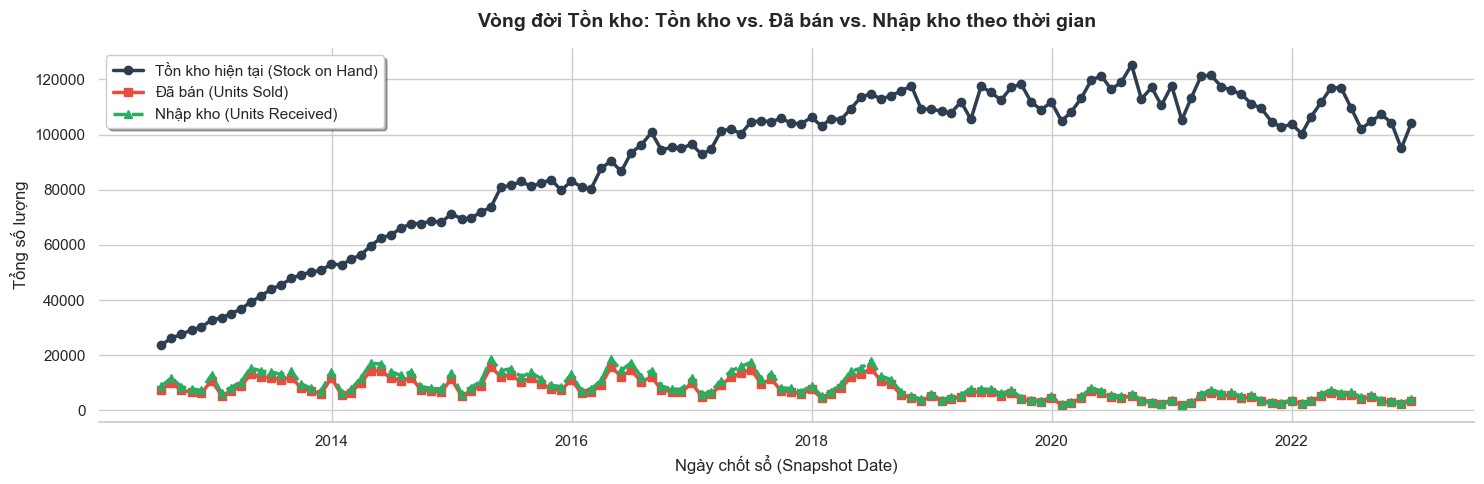

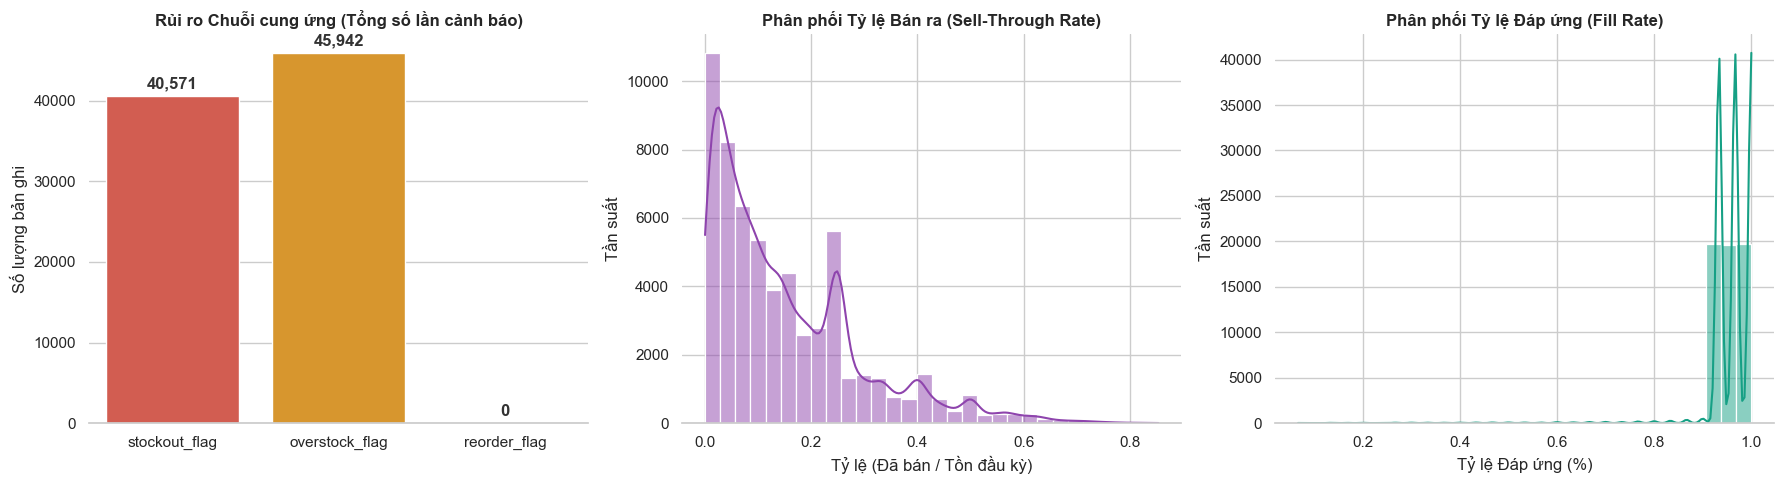

In [225]:
if 'inventory' in dfs:
    section_header("--- ĐANG TẠO DASHBOARD PHÂN TÍCH TỒN KHO ---")
    inv_df = dfs['inventory'].copy()
    
    # Ép kiểu dữ liệu thời gian cho chắc chắn
    if 'snapshot_date' in inv_df.columns:
        inv_df['snapshot_date'] = pd.to_datetime(inv_df['snapshot_date'])
        
    sns.set_theme(style="whitegrid")
    
    # ---------------------------------------------------------
    # BIỂU ĐỒ 1: XU HƯỚNG VÒNG ĐỜI TỒN KHO THEO THÁNG
    # ---------------------------------------------------------
    # Gom nhóm dữ liệu theo từng tháng snapshot
    monthly_trend = inv_df.groupby('snapshot_date')[['stock_on_hand', 'units_sold', 'units_received']].sum().reset_index()
    
    plt.figure(figsize=(15, 5))
    plt.plot(monthly_trend['snapshot_date'], monthly_trend['stock_on_hand'], 
             marker='o', label='Tồn kho hiện tại (Stock on Hand)', linewidth=2.5, color='#2c3e50')
    plt.plot(monthly_trend['snapshot_date'], monthly_trend['units_sold'], 
             marker='s', label='Đã bán (Units Sold)', linewidth=2.5, color='#e74c3c')
    plt.plot(monthly_trend['snapshot_date'], monthly_trend['units_received'], 
             marker='^', label='Nhập kho (Units Received)', linewidth=2.5, color='#27ae60', linestyle='--')
    
    plt.title('Vòng đời Tồn kho: Tồn kho vs. Đã bán vs. Nhập kho theo thời gian', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Ngày chốt sổ (Snapshot Date)', fontsize=12)
    plt.ylabel('Tổng số lượng', fontsize=12)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()
    
    # ---------------------------------------------------------
    # BIỂU ĐỒ 2, 3, 4: CỜ CẢNH BÁO & PHÂN PHỐI TỶ LỆ
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # --- Biểu đồ 2A: Số lượng cờ cảnh báo (Flags) ---
    flags = ['stockout_flag', 'overstock_flag', 'reorder_flag']
    flag_counts = []
    valid_flags = []
    for f in flags:
        if f in inv_df.columns:
            flag_counts.append(inv_df[f].sum())
            valid_flags.append(f)
            
    if valid_flags:
        sns.barplot(x=valid_flags, y=flag_counts, ax=axes[0], palette=['#e74c3c', '#f39c12', '#3498db'])
        axes[0].set_title('Rủi ro Chuỗi cung ứng (Tổng số lần cảnh báo)', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Số lượng bản ghi')
        # Thêm text con số trên đỉnh cột
        for i, v in enumerate(flag_counts):
            axes[0].text(i, v + (max(flag_counts)*0.02), f"{int(v):,}", ha='center', fontweight='bold', color='#333333')
            
    # --- Biểu đồ 2B: Phân phối Sell Through Rate ---
    if 'sell_through_rate' in inv_df.columns:
        sns.histplot(inv_df['sell_through_rate'].dropna(), bins=30, kde=True, ax=axes[1], color='#8e44ad', edgecolor='white')
        axes[1].set_title('Phân phối Tỷ lệ Bán ra (Sell-Through Rate)', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Tỷ lệ (Đã bán / Tồn đầu kỳ)')
        axes[1].set_ylabel('Tần suất')
        
    # --- Biểu đồ 2C: Phân phối Fill Rate ---
    if 'fill_rate' in inv_df.columns:
        sns.histplot(inv_df['fill_rate'].dropna(), bins=30, kde=True, ax=axes[2], color='#16a085', edgecolor='white')
        axes[2].set_title('Phân phối Tỷ lệ Đáp ứng (Fill Rate)', fontsize=12, fontweight='bold')
        axes[2].set_xlabel('Tỷ lệ Đáp ứng (%)')
        axes[2].set_ylabel('Tần suất')

    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

else:
    print("Không thể vẽ biểu đồ: Không tìm thấy bảng 'inventory' trong dữ liệu.")

#### **Phân tích Dashboard Tồn kho (Inventory Analysis Insights)**

*   **Xu hướng Tồn kho & Vòng đời:**
    *   **Lượng tồn kho (Stock on Hand)** có xu hướng tăng mạnh từ năm 2012 đến 2019 và duy trì ở mức cao sau đó. 
    *   Khoảng cách giữa tồn kho hiện tại và lượng bán thực tế đang nới rộng dần. Điều này cho thấy tốc độ nhập kho đang nhanh hơn tốc độ tiêu thụ, dẫn đến rủi ro đọng vốn.
*   **Cảnh báo Chuỗi cung ứng:**
    *   **Overstock (Dư thừa)** là rủi ro lớn nhất với gần **46,000** bản ghi ghi nhận tình trạng quá tải kho.
    *   Tình trạng **Stockout (Cạn kho)** cũng xảy ra thường xuyên (~40,000 lần), cho thấy sự mất cân đối: thừa những mặt hàng khó bán và thiếu những mặt hàng nhu cầu cao.
    *   **Reorder flag bằng 0** là một điểm bất thường cần kiểm tra lại logic hệ thống (tại sao cạn kho nhưng không có lệnh đặt hàng?).
*   **Hiệu quả Luân chuyển (Sell-Through Rate - STR):**
    *   Tỷ lệ bán ra tập trung chủ yếu ở mức thấp **(0.0 - 0.2)**. Rất ít sản phẩm đạt tỷ lệ STR trên 50%. Đây là dấu hiệu của việc luân chuyển hàng chậm, cần có chiến dịch giải phóng hàng tồn hoặc tối ưu hóa danh mục sản phẩm.
*   **Khả năng đáp ứng (Fill Rate):**
    *   Tỷ lệ đáp ứng cực kỳ ấn tượng, tập trung sát mức **1.0 (100%)**. Hệ thống đang phục vụ khách hàng rất tốt (luôn có sẵn hàng khi khách cần), nhưng cái giá phải trả chính là tình trạng dư thừa kho (Overstock) đã nêu ở trên.

**Hành động đề xuất:** Cần phân loại sản phẩm theo nhóm ABC (Dựa trên doanh thu và tốc độ bán) để giảm lượng tồn kho nhóm C (bán chậm) và tập trung nguồn lực dự trữ cho nhóm A (bán chạy) nhằm tối ưu chi phí lưu kho.


## Section 8: Phân tích Quy trình Vận hành & Hành vi Đơn hàng (Orders Analysis)
Bảng `orders` đóng vai trò là "trạm trung chuyển" dữ liệu, kết nối giữa khách hàng, thời gian và phương thức thanh toán. Tại đây, chúng ta tập trung phân tích:
1. **Trạng thái Đơn hàng (Order Status):** Xác định tỷ lệ đơn hàng thành công và rủi ro từ các đơn bị hủy/trả.
2. **Hành vi theo Thời gian (Temporal Behavior):** Phân tích các ngày trong tuần (Day of Week) để tìm ra "thời điểm vàng" khách hàng thường đặt hàng.
3. **Kênh đặt hàng & Thiết bị:** Hiểu rõ khách hàng đến từ đâu và họ ưu tiên sử dụng thiết bị nào.

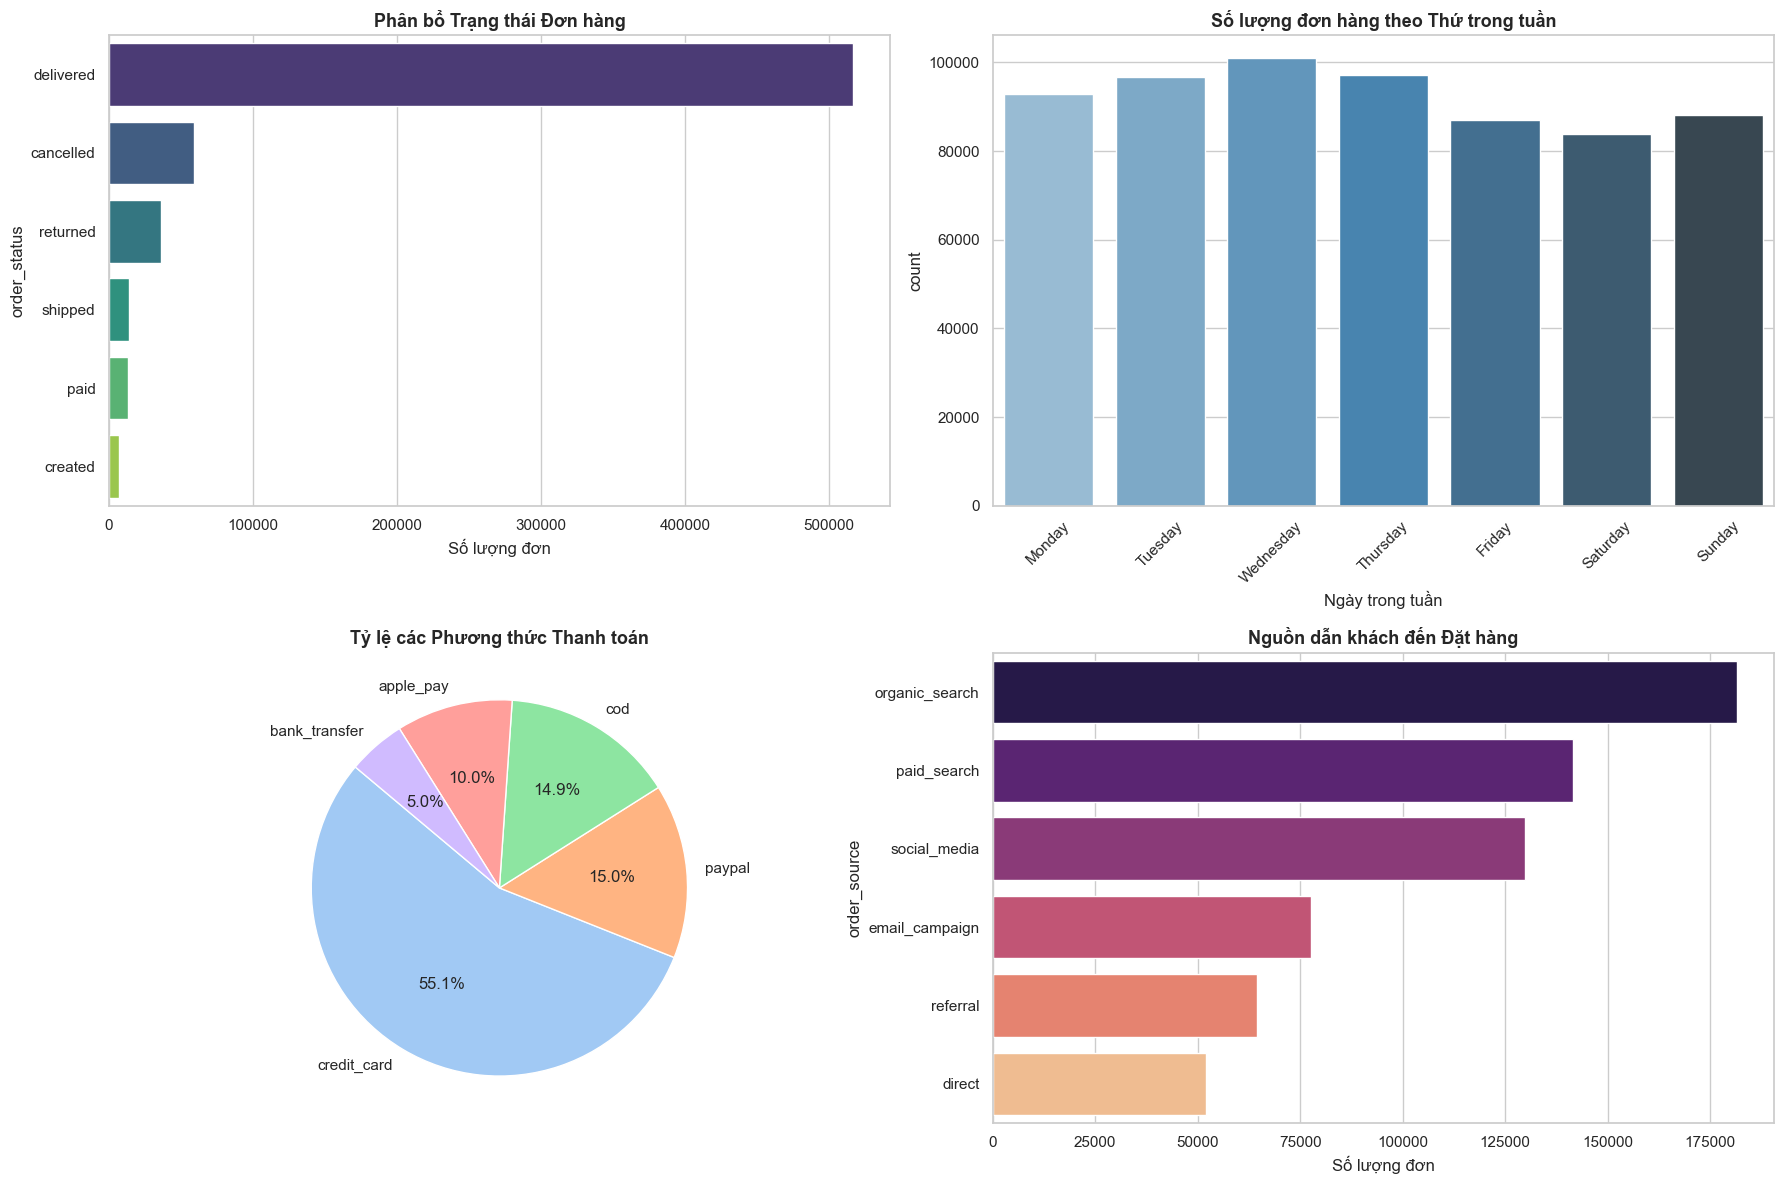

Tỷ lệ giao hàng thành công (Delivered): 79.87%
Ngày cao điểm trong tuần: Wednesday


In [224]:
if 'orders' in dfs:
    section_header("--- ĐANG PHÂN TÍCH CHI TIẾT FILE ORDERS ---")
    orders_df = dfs['orders'].copy()
    orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
    
    # 1. Tạo các đặc trưng thời gian
    orders_df['day_of_week'] = orders_df['order_date'].dt.day_name()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # --- Biểu đồ 1: Trạng thái đơn hàng ---
    status_counts = orders_df['order_status'].value_counts()
    sns.barplot(x=status_counts.values, y=status_counts.index, ax=axes[0, 0], palette='viridis')
    axes[0, 0].set_title('Phân bổ Trạng thái Đơn hàng', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Số lượng đơn')

    # --- Biểu đồ 2: Đơn hàng theo ngày trong tuần ---
    sns.countplot(data=orders_df, x='day_of_week', order=day_order, ax=axes[0, 1], palette='Blues_d')
    axes[0, 1].set_title('Số lượng đơn hàng theo Thứ trong tuần', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Ngày trong tuần')
    axes[0, 1].tick_params(axis='x', rotation=45)

    # --- Biểu đồ 3: Phương thức thanh toán phổ biến ---
    pay_counts = orders_df['payment_method'].value_counts()
    axes[1, 0].pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%', startangle=140, 
                   colors=sns.color_palette('pastel'))
    axes[1, 0].set_title('Tỷ lệ các Phương thức Thanh toán', fontsize=13, fontweight='bold')

    # --- Biểu đồ 4: Nguồn đơn hàng (Order Source) ---
    sns.countplot(data=orders_df, y='order_source', ax=axes[1, 1], palette='magma', 
                  order=orders_df['order_source'].value_counts().index)
    axes[1, 1].set_title('Nguồn dẫn khách đến Đặt hàng', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Số lượng đơn')

    plt.tight_layout()
    plt.show()

    # Thống kê nhanh ra text
    delivered_rate = (orders_df['order_status'] == 'delivered').mean() * 100
    print(f"Tỷ lệ giao hàng thành công (Delivered): {delivered_rate:.2f}%")
    print(f"Ngày cao điểm trong tuần: {orders_df['day_of_week'].mode()[0]}")

#### **Phân tích Hành vi Đơn hàng & Nguồn dẫn (Orders & Traffic Insights)**

*   **Trạng thái đơn hàng:** Phần lớn đơn hàng ở trạng thái **Delivered**, tuy nhiên tổng tỷ lệ **Cancelled** và **Returned** chiếm khoảng **15%**. Đây được xem là "dòng tiền rò rỉ" (revenue leakage), cần phân tích sâu hơn để giảm thiểu tỷ lệ này trong các bước sau.
*   **Xu hướng theo ngày trong tuần:** Đáng chú ý khi lượng đơn hàng **đạt đỉnh vào Thứ Tư (Wednesday)** và có xu hướng giảm dần vào cuối tuần (Thứ Sáu, Thứ Bảy). Đây là hành vi mua sắm đặc thù, cho thấy khách hàng thường chốt đơn vào giữa tuần để kịp nhận hàng trước cuối tuần.
*   **Thanh toán:** **Thẻ tín dụng (Credit Card)** chiếm tỷ lệ áp đảo với hơn **55%**, cho thấy tệp khách hàng có thói quen thanh toán điện tử cao. Các phương thức như COD và Paypal chia đều vị trí thứ hai (~15%).
*   **Kênh dẫn khách:** **Organic Search** là nguồn mang lại nhiều đơn hàng nhất, khẳng định sức mạnh của nội dung tự nhiên và SEO. Tiếp sau đó là Paid Search và Social Media, cho thấy sự kết hợp đa kênh đang mang lại hiệu quả tốt.

**Insight quan trọng:** Việc khách bận rộn mua sắm vào giữa tuần và ưu tiên dùng thẻ tín dụng gợi ý rằng tệp khách hàng mục tiêu nhiều khả năng là dân văn phòng hoặc người làm việc bận rộn, ưu tiên sự tiện lợi và tốc độ.


---
## SECTION 9: SUMMARY & CONCLUSION


In [226]:
section_header("SECTION 9: SUMMARY & CONCLUSION", "Tong hop van de & ket luan chat luong du lieu")

### 9A. Tóm tắt kết quả Khám phá (Key Findings)

| Khía cạnh | Tình trạng | Nhận định cốt lõi |
|:---|:---:|:---|
| **Toàn vẹn dữ liệu** | Perfect | PK/FK 100% khớp, không có bản ghi mồ côi hay trùng lặp. |
| **Tính liên tục** | Excellent | 3,833 ngày liên tục (10.5 năm), không khuyết một ngày giao dịch nào. |
| **Dữ liệu thiếu** | Structural | Chỉ thiếu ở mảng Khuyến mãi (Structural Missing) - mang ý nghĩa nghiệp vụ. |
| **Lỗi hệ thống** | Detected | Phát hiện lỗi Hoán đổi cột (Swap Error) Revenue/COGS trong 382 dòng. |
| **Ngoại lai (Outliers)** | Seasonal | Outliers của Revenue là các đỉnh doanh thu thực tế (Payday/Mega Sale). |
| **Tài chính & Web** | Consistent | Doanh thu khớp 95.4% với Thanh toán; Traffic tương quan thuận với Sales. |

---

### 9B. Chiến lược Tiếp theo (Next Steps Strategy)

Dựa trên những Insights đã tìm được, nhóm sẽ áp dụng 3 chiến lược xử lý dữ liệu trọng tâm cho **Notebook 02 (Data Preprocessing & Feature Engineering)**:

####  Chiến lược 1: Sửa lỗi & Làm sạch (Cleaning Strategy)
* **Khôi phục Margin:** Thực hiện hoán đổi ngược (Swap back) giá trị giữa `Revenue` và `COGS` cho 382 dòng lỗi đã phát hiện để bảo toàn logic lợi nhuận.
* **Lấp đầy khoảng trống:** Điền `NaN` trong bảng Promotions thành `'No_Promo'` hoặc `'Sitewide'` để biến dữ liệu khuyết thành các biến phân loại có giá trị.
* **Đồng nhất hóa:** Đảm bảo toàn bộ định dạng ngày tháng và chuỗi văn bản đồng bộ trước khi gộp bảng (Merge).

#### Chiến lược 2: Kỹ nghệ Đặc trưng (Feature Engineering)
* **Gắn nhãn sự kiện:** Tạo biến Boolean `is_peak_day` cho các ngày Outliers và `is_holiday` để mô hình học được quy luật bùng nổ doanh số.
* **Xử lý Đa cộng tuyến:** Chỉ chọn biến `Sessions` đại diện cho lưu lượng Web (loại bỏ `Page_views`, `Unique_visitors` vì tương quan > 0.9).
* **Vận hành & Kho:** Tạo biến `stock_status` (Stockout/Normal/Overstock) từ bảng Inventory để làm đầu vào dự báo rủi ro doanh thu.

#### Chiến lược 3: Chuẩn bị Mô hình (Modeling Readiness)
* **Target Variable:** Xác định `Net Revenue` (Doanh thu sau khi trừ trả hàng/hủy đơn) làm biến mục tiêu chính.
* **Granularity:** Thống nhất dữ liệu về mức hạt **Ngày (Daily)** để phù hợp với bài toán Time-Series Forecasting.

---

### KẾT LUẬN CUỐI CÙNG
Dữ liệu của dự án có chất lượng **Rất cao (High Integrity)**. Các vấn đề phát hiện được (Swap error, Structural Missing) đều đã có phương án xử lý triệt để.
